# Хорды, механизмы адаптации и цена адаптации ЛЖ

## Цель ноутбука

В этом ноутбуке проверяется идея, что ложные хорды ЛЖ могут быть связаны не напрямую с глобальной функцией сердца, а с тем, какой механизм адаптации ЛЖ формируется при нагрузке и какую “цену” эта адаптация имеет для региональной механики.

Под “механизмом адаптации” здесь понимается принадлежность пациента к одному из механико-гемодинамических фенотипов, выделенных по переменным:

- `dsws` — прирост САД на нагрузке;
- `echo_lv_sws_delta_g_cm2` — прирост систолического напряжения стенки ЛЖ;
- `echo_lv_sphericity_index_end_systolic_ratio` — индекс сферичности ЛЖ в конце систолы;
- `echo_lv_sphericity_index_end_diastolic_ratio` — индекс сферичности ЛЖ в конце диастолы.

Под “ценой адаптации” понимается степень региональной механической неоднородности, которую можно оценить через:

- `echo_lv_strain_plus_cv_pct`;
- `echo_lv_strain_rate_cv_pct`;
- `dicor_ssou_cv_pct`;
- `dicor_sm_kdtr_cv_pct`.

## Основная физиологическая идея

Ложные хорды ЛЖ рассматриваются как возможные внутренние механические ограничения. Они могут не снижать EF напрямую, но потенциально могут менять распределение нагрузки внутри ЛЖ.

Поэтому основной вопрос:

> Связаны ли разные типы хорд с разными механизмами адаптации ЛЖ и с разной ценой этой адаптации?

## Рабочие гипотезы

### H1. Архитектура хорд связана с механизмом адаптации

Поперечные, distant и complex/multi-zone хорды могут чаще встречаться в стресс-доминантном фенотипе адаптации.

### H2. Количество хорд менее важно, чем их ориентация и топология

Простое количество хорд может быть слабее связано с механикой, чем ориентация, распространённость и топология хорд.

### H3. Стресс-доминантный фенотип может иметь большую цену адаптации

Ожидается, что стресс-доминантный фенотип будет связан с более высокой вариабельностью strain, strain rate и DICOR-показателей.

### H4. Геометрически-сферичный фенотип может быть компенсаторным

Более сферичная геометрия ЛЖ не обязательно означает большую механическую неоднородность. Она может быть отдельным вариантом адаптации.

### H5. Самая высокая цена адаптации может возникать при сочетании:

```text
сложная / поперечная архитектура хорд
+
стресс-доминантный фенотип адаптации

In [18]:
# ============================================================
# 0. Минимальная служебная ячейка: импорты и пути
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 180)

PROJECT_ROOT = Path(
    r"C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords"
)

DATA_PATH = PROJECT_ROOT / "data" / "final_analysis_dataset_ver2.xlsx"

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "05_chords_adaptation_costs"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Импорты загружены")
print("DATA_PATH:", DATA_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)

Импорты загружены
DATA_PATH: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\data\final_analysis_dataset_ver2.xlsx
OUTPUT_DIR: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\05_chords_adaptation_costs


In [19]:
# ============================================================
# 1. Загрузка данных и определение групп переменных
# ============================================================

df = pd.read_excel(DATA_PATH)

print(f"Размер исходного датасета: {df.shape[0]} строк × {df.shape[1]} колонок")

# ------------------------------------------------------------
# Переменные механизма адаптации
# ------------------------------------------------------------

adaptation_vars = [
    "dsws",
    "echo_lv_sws_delta_g_cm2",
    "echo_lv_sphericity_index_end_systolic_ratio",
    "echo_lv_sphericity_index_end_diastolic_ratio",
]

# ------------------------------------------------------------
# Переменные хорд
# ------------------------------------------------------------

chord_vars = [
    "lv_false_tendon_total_count",
    "Chord_Orientation",
    "Chord_Spread_Class",
    "Chord_Topology_Class",
]

# ------------------------------------------------------------
# Переменные “цены адаптации”
# ------------------------------------------------------------

adaptation_cost_vars = [
    "echo_lv_strain_plus_cv_pct",
    "echo_lv_strain_rate_cv_pct",
    "dicor_ssou_cv_pct",
    "dicor_sm_kdtr_cv_pct",
]

# ------------------------------------------------------------
# Базовые ковариаты, если понадобятся позже
# ------------------------------------------------------------

baseline_covariates = [
    "age_years",
    "sex",
    "body_surface_area_m2",
    "body_mass_index_kg_m2",
]

# ------------------------------------------------------------
# Красивые названия для графиков
# ------------------------------------------------------------

pretty_names = {
    "dsws": "ΔСАД на нагрузке, мм рт. ст.",
    "echo_lv_sws_delta_g_cm2": "ΔSWS ЛЖ, г/см²",
    "echo_lv_sphericity_index_end_systolic_ratio": "Индекс сферичности ЛЖ, КС",
    "echo_lv_sphericity_index_end_diastolic_ratio": "Индекс сферичности ЛЖ, КД",

    "lv_false_tendon_total_count": "Количество ложных хорд",
    "Chord_Orientation": "Ориентация хорд",
    "Chord_Spread_Class": "Распространённость хорд",
    "Chord_Topology_Class": "Топология хорд",

    "echo_lv_strain_plus_cv_pct": "CV strain, %",
    "echo_lv_strain_rate_cv_pct": "CV strain rate, %",
    "dicor_ssou_cv_pct": "DICOR CV ССОУ, %",
    "dicor_sm_kdtr_cv_pct": "DICOR CV КДТР, %",
}

# ------------------------------------------------------------
# Проверка наличия переменных
# ------------------------------------------------------------

variable_groups = {
    "adaptation_vars": adaptation_vars,
    "chord_vars": chord_vars,
    "adaptation_cost_vars": adaptation_cost_vars,
    "baseline_covariates": baseline_covariates,
}

for group_name, vars_list in variable_groups.items():
    existing = [col for col in vars_list if col in df.columns]
    missing = [col for col in vars_list if col not in df.columns]

    print(f"\n{group_name}")
    print("  Найдены:", existing)
    print("  Не найдены:", missing)

Размер исходного датасета: 153 строк × 222 колонок

adaptation_vars
  Найдены: ['dsws', 'echo_lv_sws_delta_g_cm2', 'echo_lv_sphericity_index_end_systolic_ratio', 'echo_lv_sphericity_index_end_diastolic_ratio']
  Не найдены: []

chord_vars
  Найдены: ['lv_false_tendon_total_count']
  Не найдены: ['Chord_Orientation', 'Chord_Spread_Class', 'Chord_Topology_Class']

adaptation_cost_vars
  Найдены: ['echo_lv_strain_plus_cv_pct', 'echo_lv_strain_rate_cv_pct', 'dicor_ssou_cv_pct', 'dicor_sm_kdtr_cv_pct']
  Не найдены: []

baseline_covariates
  Найдены: ['sex']
  Не найдены: ['age_years', 'body_surface_area_m2', 'body_mass_index_kg_m2']


In [46]:
# ============================================================
# 17. Восстановление архитектурных переменных хорд
# ============================================================

# Косые хорды
oblique_cols = [
    "lv_false_tendon_apical_oblique_count",
    "lv_false_tendon_mid_oblique_count",
    "lv_false_tendon_basal_oblique_count",
    "lv_false_tendon_mid_to_basal_oblique_count",
    "lv_false_tendon_mid_to_apical_oblique_count",
    "lv_false_tendon_basal_to_apical_oblique_count",
]

# Поперечные хорды
transverse_cols = [
    "lv_false_tendon_apical_transverse_count",
    "lv_false_tendon_mid_transverse_count",
    "lv_false_tendon_mid_and_basal_transverse_count",
    "lv_false_tendon_basal_transverse_count",
]

all_orientation_cols = oblique_cols + transverse_cols

missing_orientation_cols = [
    col for col in all_orientation_cols
    if col not in df.columns
]

if missing_orientation_cols:
    print("Не найдены сегментарные переменные для восстановления ориентации хорд:")
    for col in missing_orientation_cols:
        print("-", col)
else:
    print("Все переменные для восстановления ориентации хорд найдены.")

    # Пропуски в счётчиках хорд трактуем как 0
    for col in all_orientation_cols:
        df[col] = df[col].fillna(0)

    df["oblique_total"] = df[oblique_cols].sum(axis=1)
    df["transverse_total"] = df[transverse_cols].sum(axis=1)

    df["Chord_Orientation"] = np.select(
        [
            df["transverse_total"] > 0,
            (df["transverse_total"] == 0) & (df["oblique_total"] > 0),
        ],
        [
            "Transverse-Involved",
            "Oblique-Only",
        ],
        default="Unclassified",
    )

    # Для совместимости с предыдущим ноутбуком
    df["mechanical_chord_phenotype"] = df["Chord_Orientation"]

    print("\nРаспределение Chord_Orientation:")
    display(df["Chord_Orientation"].value_counts(dropna=False))

    display(
        df[
            [
                "oblique_total",
                "transverse_total",
                "Chord_Orientation",
            ]
        ].head()
    )

Все переменные для восстановления ориентации хорд найдены.

Распределение Chord_Orientation:


Chord_Orientation
Transverse-Involved    83
Unclassified           55
Oblique-Only           15
Name: count, dtype: int64

,oblique_total,transverse_total,Chord_Orientation
0,4.0,1.0,Transverse-Involved
1,0.0,0.0,Unclassified
2,2.0,5.0,Transverse-Involved
3,1.0,6.0,Transverse-Involved
4,0.0,0.0,Unclassified


In [20]:
# ============================================================
# 2. Аудит ключевых переменных
# ============================================================

all_key_vars = adaptation_vars + chord_vars + adaptation_cost_vars + baseline_covariates
all_key_vars_existing = [col for col in all_key_vars if col in df.columns]

audit_table = pd.DataFrame({
    "variable": all_key_vars_existing,
    "dtype": [str(df[col].dtype) for col in all_key_vars_existing],
    "n_non_missing": [df[col].notna().sum() for col in all_key_vars_existing],
    "n_missing": [df[col].isna().sum() for col in all_key_vars_existing],
    "pct_missing": [(df[col].isna().mean() * 100).round(2) for col in all_key_vars_existing],
    "n_unique": [df[col].nunique(dropna=True) for col in all_key_vars_existing],
})

display(audit_table)

audit_table.to_excel(TABLES_DIR / "00_key_variables_audit.xlsx", index=False)

print("Таблица сохранена:", TABLES_DIR / "00_key_variables_audit.xlsx")

,variable,dtype,n_non_missing,n_missing,pct_missing,n_unique
0,dsws,float64,66,87,56.86,30
1,echo_lv_sws_delta_g_cm2,float64,33,120,78.43,33
2,echo_lv_sphericity_index_end_systolic_ratio,float64,100,53,34.64,74
3,echo_lv_sphericity_index_end_diastolic_ratio,float64,100,53,34.64,72
4,lv_false_tendon_total_count,float64,132,21,13.73,7
5,echo_lv_strain_plus_cv_pct,float64,32,121,79.08,32
6,echo_lv_strain_rate_cv_pct,float64,32,121,79.08,32
7,dicor_ssou_cv_pct,float64,68,85,55.56,68
8,dicor_sm_kdtr_cv_pct,float64,68,85,55.56,56
9,sex,float64,105,48,31.37,2


Таблица сохранена: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\05_chords_adaptation_costs\tables\00_key_variables_audit.xlsx


In [21]:
# ============================================================
# 3. Реконструкция механико-гемодинамических фенотипов
# ============================================================

# Рабочая таблица только по переменным адаптации
adaptation_df = df[adaptation_vars].copy()

complete_adaptation_mask = adaptation_df.notna().all(axis=1)
adaptation_complete = adaptation_df.loc[complete_adaptation_mask].copy()

print(f"Всего наблюдений в датасете: {df.shape[0]}")
print(f"Полные случаи по переменным адаптации: {adaptation_complete.shape[0]}")

# ------------------------------------------------------------
# Поиск экстремального ΔSWS через IQR
# ------------------------------------------------------------

sws_col = "echo_lv_sws_delta_g_cm2"

q1 = adaptation_complete[sws_col].quantile(0.25)
q3 = adaptation_complete[sws_col].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

sws_outlier_mask = (
    (adaptation_complete[sws_col] < lower_bound) |
    (adaptation_complete[sws_col] > upper_bound)
)

sws_outliers = adaptation_complete.loc[sws_outlier_mask].copy()
adaptation_no_outlier = adaptation_complete.loc[~sws_outlier_mask].copy()

print("\nГраницы выбросов по ΔSWS:")
print("lower_bound:", round(lower_bound, 2))
print("upper_bound:", round(upper_bound, 2))

print(f"\nКоличество экстремальных наблюдений по ΔSWS: {sws_outliers.shape[0]}")
display(sws_outliers)

print(f"\nРазмер выборки без экстремального ΔSWS: {adaptation_no_outlier.shape[0]}")

# ------------------------------------------------------------
# Z-стандартизация
# ------------------------------------------------------------

scaler = StandardScaler()

X_adaptation_scaled_array = scaler.fit_transform(adaptation_no_outlier[adaptation_vars])

X_adaptation_scaled = pd.DataFrame(
    X_adaptation_scaled_array,
    columns=adaptation_vars,
    index=adaptation_no_outlier.index,
)

# ------------------------------------------------------------
# KMeans k=3
# ------------------------------------------------------------

kmeans_3 = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=50,
)

labels_kmeans_3 = kmeans_3.fit_predict(X_adaptation_scaled)

adaptation_clusters = adaptation_no_outlier.copy()
adaptation_clusters["adaptation_cluster_k3"] = labels_kmeans_3

print("\nРазмеры кластеров:")
display(adaptation_clusters["adaptation_cluster_k3"].value_counts().sort_index())

# ------------------------------------------------------------
# Z-профили кластеров
# ------------------------------------------------------------

X_adaptation_scaled_with_clusters = X_adaptation_scaled.copy()
X_adaptation_scaled_with_clusters["adaptation_cluster_k3"] = labels_kmeans_3

z_profile_adaptation_k3 = (
    X_adaptation_scaled_with_clusters
    .groupby("adaptation_cluster_k3")[adaptation_vars]
    .mean()
)

display(z_profile_adaptation_k3.round(2))

Всего наблюдений в датасете: 153
Полные случаи по переменным адаптации: 27

Границы выбросов по ΔSWS:
lower_bound: -16.26
upper_bound: 63.06

Количество экстремальных наблюдений по ΔSWS: 1


,dsws,echo_lv_sws_delta_g_cm2,echo_lv_sphericity_index_end_systolic_ratio,echo_lv_sphericity_index_end_diastolic_ratio
55,21.0,135.312821,0.472,0.469



Размер выборки без экстремального ΔSWS: 26

Размеры кластеров:


adaptation_cluster_k3
0     9
1    10
2     7
Name: count, dtype: int64

,dsws,echo_lv_sws_delta_g_cm2,echo_lv_sphericity_index_end_systolic_ratio,echo_lv_sphericity_index_end_diastolic_ratio
adaptation_cluster_k3,,,,
0,0.27,0.08,0.93,1.04
1,-0.66,-0.80,-0.71,-0.34
2,0.59,1.05,-0.18,-0.85


In [22]:
# ============================================================
# 4. Осмысленные названия фенотипов адаптации
# ============================================================

# По ранее полученному профилю:
# cluster 0 = высокая сферичность, умеренная нагрузка
# cluster 1 = низкая нагрузка и менее сферичная геометрия
# cluster 2 = высокий dsws и высокий ΔSWS, но без сферизации

cluster_name_map = {
    0: "Sphericity-dominant phenotype",
    1: "Low load / low sphericity phenotype",
    2: "Stress-dominant phenotype",
}

cluster_name_map_ru = {
    0: "Геометрически-сферичный фенотип",
    1: "Низконагрузочный менее сферичный фенотип",
    2: "Стресс-доминантный фенотип",
}

adaptation_clusters["adaptation_phenotype"] = (
    adaptation_clusters["adaptation_cluster_k3"]
    .map(cluster_name_map)
)

adaptation_clusters["adaptation_phenotype_ru"] = (
    adaptation_clusters["adaptation_cluster_k3"]
    .map(cluster_name_map_ru)
)

# Экстремальный ΔSWS сохраняем отдельно, не смешиваем с основными кластерами
extreme_sws_df = sws_outliers.copy()
extreme_sws_df["adaptation_cluster_k3"] = pd.NA
extreme_sws_df["adaptation_phenotype"] = "Extreme ΔSWS case"
extreme_sws_df["adaptation_phenotype_ru"] = "Экстремальный ΔSWS"

# Общая таблица фенотипов
adaptation_phenotypes = pd.concat(
    [
        adaptation_clusters,
        extreme_sws_df,
    ],
    axis=0
).sort_index()

display(adaptation_phenotypes[["adaptation_cluster_k3", "adaptation_phenotype_ru"]].head())

print("Распределение фенотипов:")
display(adaptation_phenotypes["adaptation_phenotype_ru"].value_counts(dropna=False))

,adaptation_cluster_k3,adaptation_phenotype_ru
0,2,Стресс-доминантный фенотип
2,0,Геометрически-сферичный фенотип
3,2,Стресс-доминантный фенотип
4,0,Геометрически-сферичный фенотип
5,1,Низконагрузочный менее сферичный фенотип


Распределение фенотипов:


adaptation_phenotype_ru
Низконагрузочный менее сферичный фенотип    10
Геометрически-сферичный фенотип              9
Стресс-доминантный фенотип                   7
Экстремальный ΔSWS                           1
Name: count, dtype: int64

In [23]:
# ============================================================
# 5. Объединение фенотипов адаптации с хордами и ценой адаптации
# ============================================================

analysis_vars = (
    ["adaptation_cluster_k3", "adaptation_phenotype", "adaptation_phenotype_ru"]
    + adaptation_vars
    + chord_vars
    + adaptation_cost_vars
    + baseline_covariates
)

existing_analysis_vars = [
    col for col in analysis_vars
    if col in adaptation_phenotypes.columns or col in df.columns
]

analysis_df = df.copy()

# Добавляем кластерные метки
analysis_df = analysis_df.join(
    adaptation_phenotypes[
        ["adaptation_cluster_k3", "adaptation_phenotype", "adaptation_phenotype_ru"]
    ],
    how="left"
)

# Берём только нужные переменные, которые реально есть
analysis_existing_cols = [
    col for col in analysis_vars
    if col in analysis_df.columns
]

analysis_df = analysis_df[analysis_existing_cols].copy()

print("Размер analysis_df:", analysis_df.shape)

display(analysis_df.head())

analysis_df.to_excel(TABLES_DIR / "01_analysis_dataset_with_adaptation_phenotypes.xlsx", index=True)

print("Таблица сохранена:", TABLES_DIR / "01_analysis_dataset_with_adaptation_phenotypes.xlsx")

Размер analysis_df: (153, 13)


,adaptation_cluster_k3,adaptation_phenotype,adaptation_phenotype_ru,dsws,echo_lv_sws_delta_g_cm2,echo_lv_sphericity_index_end_systolic_ratio,echo_lv_sphericity_index_end_diastolic_ratio,lv_false_tendon_total_count,echo_lv_strain_plus_cv_pct,echo_lv_strain_rate_cv_pct,dicor_ssou_cv_pct,dicor_sm_kdtr_cv_pct,sex
0,2,Stress-dominant phenotype,Стресс-доминантный фенотип,37.0,35.371669,0.463,0.343,1.0,NaN,NaN,27.282681,15.713484,1.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,1.0
2,0,Sphericity-dominant phenotype,Геометрически-сферичный фенотип,42.0,38.579679,0.505,0.602,4.0,NaN,NaN,16.148942,28.571429,1.0
3,2,Stress-dominant phenotype,Стресс-доминантный фенотип,46.0,40.536860,0.514,0.400,3.0,NaN,NaN,41.583903,4.651163,1.0
4,0,Sphericity-dominant phenotype,Геометрически-сферичный фенотип,21.0,26.281070,0.576,0.530,3.0,NaN,NaN,NaN,NaN,1.0


Таблица сохранена: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\05_chords_adaptation_costs\tables\01_analysis_dataset_with_adaptation_phenotypes.xlsx


In [24]:
# ============================================================
# 6. Описание фенотипов адаптации в исходных единицах
# ============================================================

phenotype_order_ru = [
    "Низконагрузочный менее сферичный фенотип",
    "Геометрически-сферичный фенотип",
    "Стресс-доминантный фенотип",
    "Экстремальный ΔSWS",
]

phenotype_profile_raw = (
    analysis_df
    .dropna(subset=["adaptation_phenotype_ru"])
    .groupby("adaptation_phenotype_ru")[adaptation_vars]
    .agg(["count", "mean", "std", "median", "min", "max"])
)

display(phenotype_profile_raw)

phenotype_profile_raw.to_excel(TABLES_DIR / "02_adaptation_phenotype_profiles_raw.xlsx")

dsws                                          echo_lv_sws_delta_g_cm2                                                             \
                                         count       mean        std median   min   max                   count        mean        std      median         min         max   
adaptation_phenotype_ru                                                                                                                                                      
Геометрически-сферичный фенотип              9  26.444444  10.477489   21.0  14.0  42.0                       9   22.780385  11.353817   21.944419    4.398595   39.878423   
Низконагрузочный менее сферичный фенотип    10  15.400000  11.007068   18.0  -3.0  29.0                      10   12.952005   5.771177   13.480682    3.042909   22.112423   
Стресс-доминантный фенотип                   7  30.285714  10.609968   31.0  12.0  46.0                       7   33.675450   5.080836   35.371669   24.801222   40.536860   
Экстремальный ΔSWS                           1  21.000000        NaN   21.0  21.0  21.0                       1  135.312821        NaN  135.312821  135.312821  135.312821   

                                         echo_lv_sphericity_index_end_systolic_ratio                                          echo_lv_sphericity_index_end_diastolic_ratio  \
                                                                               count      mean       std median    min    max                                        count   
adaptation_phenotype_ru                                                                                                                                                      
Геометрически-сферичный фенотип                                                    9  0.489667  0.044682  0.480  0.438  0.576                                            9   
Низконагрузочный менее сферичный фенотип                                          10  0.388000  0.044422  0.371  0.349  0.487                                           10   
Стресс-доминантный фенотип                                                         7  0.420714  0.050642  0.400  0.373  0.514                                            7   
Экстремальный ΔSWS                                                                 1  0.472000       NaN  0.472  0.472  0.472                                            1   

                                                                                   
                                              mean       std median    min    max  
adaptation_phenotype_ru                                                            
Геометрически-сферичный фенотип           0.551111  0.028989  0.547  0.516  0.602  
Низконагрузочный менее сферичный фенотип  0.465500  0.044142  0.465  0.370  0.535  
Стресс-доминантный фенотип                0.434143  0.048790  0.444  0.343  0.489  
Экстремальный ΔSWS                        0.469000       NaN  0.469  0.469  0.469

In [25]:
# ============================================================
# Обновление переменных “цены адаптации”
# ============================================================

integral_cost_var = "merged_lv_deformation_cv_pct"

adaptation_cost_vars = [
    "echo_lv_strain_plus_cv_pct",
    "echo_lv_strain_rate_cv_pct",
    "dicor_ssou_cv_pct",
    "dicor_sm_kdtr_cv_pct",
]

if integral_cost_var in df.columns:
    adaptation_cost_vars.append(integral_cost_var)
    print("Интегральная переменная добавлена:", integral_cost_var)
else:
    print("ВНИМАНИЕ: переменная не найдена в df:", integral_cost_var)

pretty_names.update({
    "merged_lv_deformation_cv_pct": "Интегральный CV деформации ЛЖ, %",
    "echo_lv_strain_plus_cv_pct": "CV strain, %",
    "echo_lv_strain_rate_cv_pct": "CV strain rate, %",
    "dicor_ssou_cv_pct": "DICOR CV ССОУ, %",
    "dicor_sm_kdtr_cv_pct": "DICOR CV КДТР, %",
})

print("\nИтоговый список переменных цены адаптации:")
for col in adaptation_cost_vars:
    status = "найдена" if col in df.columns else "не найдена"
    print(f"- {col}: {status}")

Интегральная переменная добавлена: merged_lv_deformation_cv_pct

Итоговый список переменных цены адаптации:
- echo_lv_strain_plus_cv_pct: найдена
- echo_lv_strain_rate_cv_pct: найдена
- dicor_ssou_cv_pct: найдена
- dicor_sm_kdtr_cv_pct: найдена
- merged_lv_deformation_cv_pct: найдена


In [26]:
# ============================================================
# 5. Объединение фенотипов адаптации с хордами и ценой адаптации
# ============================================================

analysis_df = df.copy()

# Добавляем метки фенотипов, которые были получены в предыдущих ячейках
analysis_df = analysis_df.join(
    adaptation_phenotypes[
        [
            "adaptation_cluster_k3",
            "adaptation_phenotype",
            "adaptation_phenotype_ru",
        ]
    ],
    how="left"
)

# Собираем список нужных переменных
analysis_vars = (
    [
        "adaptation_cluster_k3",
        "adaptation_phenotype",
        "adaptation_phenotype_ru",
    ]
    + adaptation_vars
    + chord_vars
    + adaptation_cost_vars
    + baseline_covariates
)

analysis_vars_existing = [col for col in analysis_vars if col in analysis_df.columns]

analysis_df = analysis_df[analysis_vars_existing].copy()

print("Размер analysis_df:", analysis_df.shape)

print("\nРаспределение фенотипов:")
display(analysis_df["adaptation_phenotype_ru"].value_counts(dropna=False))

display(analysis_df.head())

analysis_df.to_excel(
    TABLES_DIR / "01_analysis_dataset_with_adaptation_phenotypes.xlsx",
    index=True
)

print("Таблица сохранена:", TABLES_DIR / "01_analysis_dataset_with_adaptation_phenotypes.xlsx")

Размер analysis_df: (153, 14)

Распределение фенотипов:


adaptation_phenotype_ru
NaN                                         126
Низконагрузочный менее сферичный фенотип     10
Геометрически-сферичный фенотип               9
Стресс-доминантный фенотип                    7
Экстремальный ΔSWS                            1
Name: count, dtype: int64

,adaptation_cluster_k3,adaptation_phenotype,adaptation_phenotype_ru,dsws,echo_lv_sws_delta_g_cm2,echo_lv_sphericity_index_end_systolic_ratio,echo_lv_sphericity_index_end_diastolic_ratio,lv_false_tendon_total_count,echo_lv_strain_plus_cv_pct,echo_lv_strain_rate_cv_pct,dicor_ssou_cv_pct,dicor_sm_kdtr_cv_pct,merged_lv_deformation_cv_pct,sex
0,2,Stress-dominant phenotype,Стресс-доминантный фенотип,37.0,35.371669,0.463,0.343,1.0,NaN,NaN,27.282681,15.713484,24.0,1.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,1.0
2,0,Sphericity-dominant phenotype,Геометрически-сферичный фенотип,42.0,38.579679,0.505,0.602,4.0,NaN,NaN,16.148942,28.571429,37.0,1.0
3,2,Stress-dominant phenotype,Стресс-доминантный фенотип,46.0,40.536860,0.514,0.400,3.0,NaN,NaN,41.583903,4.651163,33.0,1.0
4,0,Sphericity-dominant phenotype,Геометрически-сферичный фенотип,21.0,26.281070,0.576,0.530,3.0,NaN,NaN,NaN,NaN,NaN,1.0


Таблица сохранена: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\05_chords_adaptation_costs\tables\01_analysis_dataset_with_adaptation_phenotypes.xlsx


In [27]:
# ============================================================
# 6. Порядок фенотипов и рабочие таблицы
# ============================================================

phenotype_order_ru = [
    "Низконагрузочный менее сферичный фенотип",
    "Геометрически-сферичный фенотип",
    "Стресс-доминантный фенотип",
    "Экстремальный ΔSWS",
]

main_phenotype_order_ru = [
    "Низконагрузочный менее сферичный фенотип",
    "Геометрически-сферичный фенотип",
    "Стресс-доминантный фенотип",
]

# Основная таблица только по трём основным фенотипам.
# Экстремальный ΔSWS не удаляем из проекта, но для статистики по группам пока исключаем.
main_df = analysis_df[
    analysis_df["adaptation_phenotype_ru"].isin(main_phenotype_order_ru)
].copy()

print("Размер main_df без экстремального ΔSWS:", main_df.shape)

display(main_df["adaptation_phenotype_ru"].value_counts().reindex(main_phenotype_order_ru))

Размер main_df без экстремального ΔSWS: (26, 14)


adaptation_phenotype_ru
Низконагрузочный менее сферичный фенотип    10
Геометрически-сферичный фенотип              9
Стресс-доминантный фенотип                   7
Name: count, dtype: int64

In [28]:
# ============================================================
# 7. Профиль фенотипов адаптации в исходных единицах
# ============================================================

phenotype_profile_raw = (
    analysis_df
    .dropna(subset=["adaptation_phenotype_ru"])
    .groupby("adaptation_phenotype_ru")[adaptation_vars]
    .agg(["count", "mean", "std", "median", "min", "max"])
)

display(phenotype_profile_raw)

phenotype_profile_raw.to_excel(
    TABLES_DIR / "02_adaptation_phenotype_profiles_raw.xlsx"
)

print("Таблица сохранена:", TABLES_DIR / "02_adaptation_phenotype_profiles_raw.xlsx")

dsws                                          echo_lv_sws_delta_g_cm2                                                             \
                                         count       mean        std median   min   max                   count        mean        std      median         min         max   
adaptation_phenotype_ru                                                                                                                                                      
Геометрически-сферичный фенотип              9  26.444444  10.477489   21.0  14.0  42.0                       9   22.780385  11.353817   21.944419    4.398595   39.878423   
Низконагрузочный менее сферичный фенотип    10  15.400000  11.007068   18.0  -3.0  29.0                      10   12.952005   5.771177   13.480682    3.042909   22.112423   
Стресс-доминантный фенотип                   7  30.285714  10.609968   31.0  12.0  46.0                       7   33.675450   5.080836   35.371669   24.801222   40.536860   
Экстремальный ΔSWS                           1  21.000000        NaN   21.0  21.0  21.0                       1  135.312821        NaN  135.312821  135.312821  135.312821   

                                         echo_lv_sphericity_index_end_systolic_ratio                                          echo_lv_sphericity_index_end_diastolic_ratio  \
                                                                               count      mean       std median    min    max                                        count   
adaptation_phenotype_ru                                                                                                                                                      
Геометрически-сферичный фенотип                                                    9  0.489667  0.044682  0.480  0.438  0.576                                            9   
Низконагрузочный менее сферичный фенотип                                          10  0.388000  0.044422  0.371  0.349  0.487                                           10   
Стресс-доминантный фенотип                                                         7  0.420714  0.050642  0.400  0.373  0.514                                            7   
Экстремальный ΔSWS                                                                 1  0.472000       NaN  0.472  0.472  0.472                                            1   

                                                                                   
                                              mean       std median    min    max  
adaptation_phenotype_ru                                                            
Геометрически-сферичный фенотип           0.551111  0.028989  0.547  0.516  0.602  
Низконагрузочный менее сферичный фенотип  0.465500  0.044142  0.465  0.370  0.535  
Стресс-доминантный фенотип                0.434143  0.048790  0.444  0.343  0.489  
Экстремальный ΔSWS                        0.469000       NaN  0.469  0.469  0.469

Таблица сохранена: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\05_chords_adaptation_costs\tables\02_adaptation_phenotype_profiles_raw.xlsx


In [29]:
# ============================================================
# Служебная ячейка: стиль графиков
# ============================================================

def apply_publication_style(ax, grid_axis="y"):
    """
    Академический стиль графиков:
    белый фон, черные оси, без верхней и правой рамки.
    """

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_color("black")
    ax.spines["bottom"].set_color("black")

    ax.tick_params(axis="both", colors="black", labelsize=10)

    if grid_axis is not None:
        ax.grid(True, axis=grid_axis, alpha=0.5)

    return ax

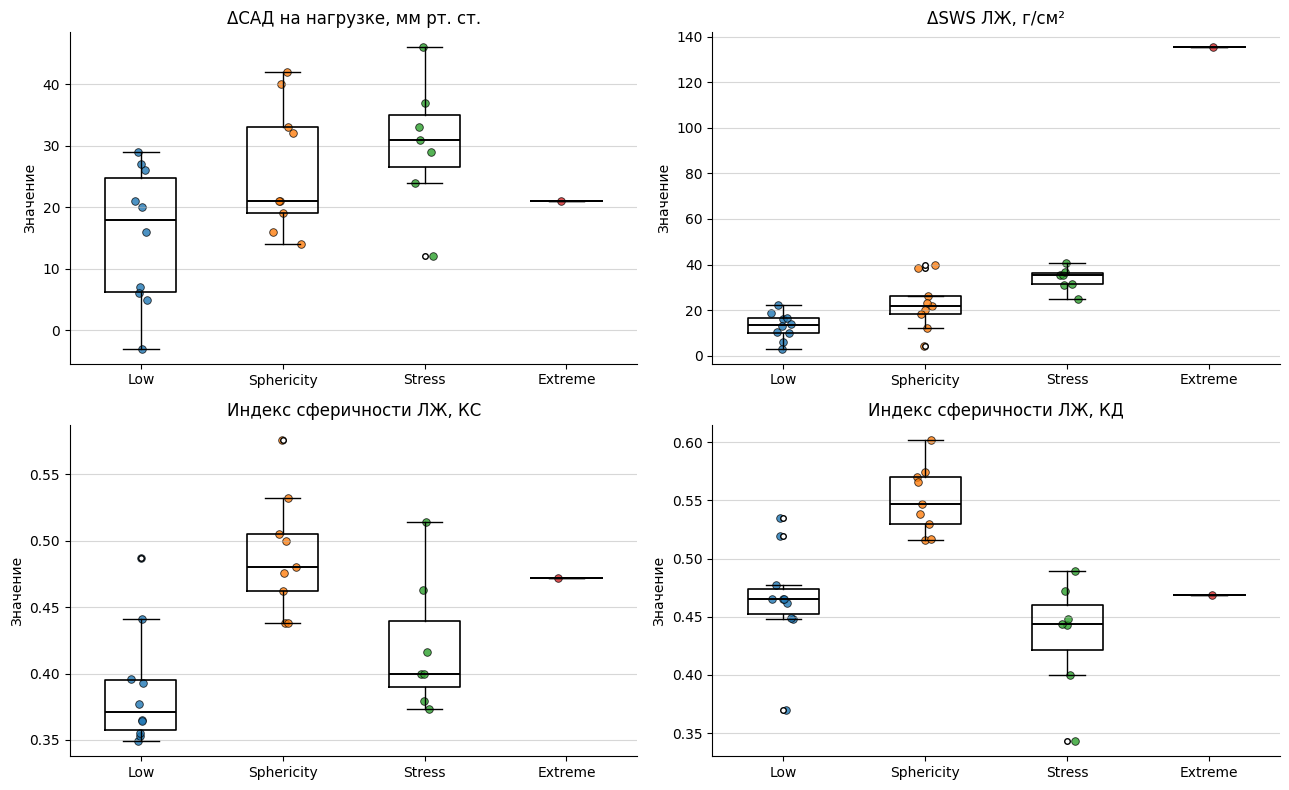

Рисунок сохранён: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\05_chords_adaptation_costs\figures\01_adaptation_variables_by_phenotype_boxplots.png


In [30]:
# ============================================================
# 8. Boxplot: переменные механизма адаптации по фенотипам
# ============================================================

plot_df = analysis_df[
    analysis_df["adaptation_phenotype_ru"].isin(phenotype_order_ru)
].copy()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for ax, col in zip(axes, adaptation_vars):
    data_by_group = [
        plot_df.loc[
            plot_df["adaptation_phenotype_ru"] == group,
            col
        ].dropna()
        for group in phenotype_order_ru
    ]

    ax.boxplot(
        data_by_group,
        patch_artist=False,
        widths=0.5,
        boxprops=dict(color="black", linewidth=1.2),
        medianprops=dict(color="black", linewidth=1.4),
        whiskerprops=dict(color="black", linewidth=1.0),
        capprops=dict(color="black", linewidth=1.0),
        flierprops=dict(
            marker="o",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=4,
        ),
    )

    # точки поверх boxplot
    for i, values in enumerate(data_by_group, start=1):
        jitter = np.random.normal(loc=i, scale=0.035, size=len(values))
        ax.scatter(
            jitter,
            values,
            s=30,
            edgecolor="black",
            linewidth=0.6,
            alpha=0.8,
        )

    ax.set_title(pretty_names.get(col, col))
    ax.set_ylabel("Значение")
    ax.set_xticklabels(
        ["Low", "Sphericity", "Stress", "Extreme"],
        rotation=0
    )

    apply_publication_style(ax)

plt.tight_layout()

fig_path = FIGURES_DIR / "01_adaptation_variables_by_phenotype_boxplots.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Рисунок сохранён:", fig_path)

Переменные цены адаптации:
- echo_lv_strain_plus_cv_pct: n=0
- echo_lv_strain_rate_cv_pct: n=0
- dicor_ssou_cv_pct: n=24
- dicor_sm_kdtr_cv_pct: n=24
- merged_lv_deformation_cv_pct: n=24


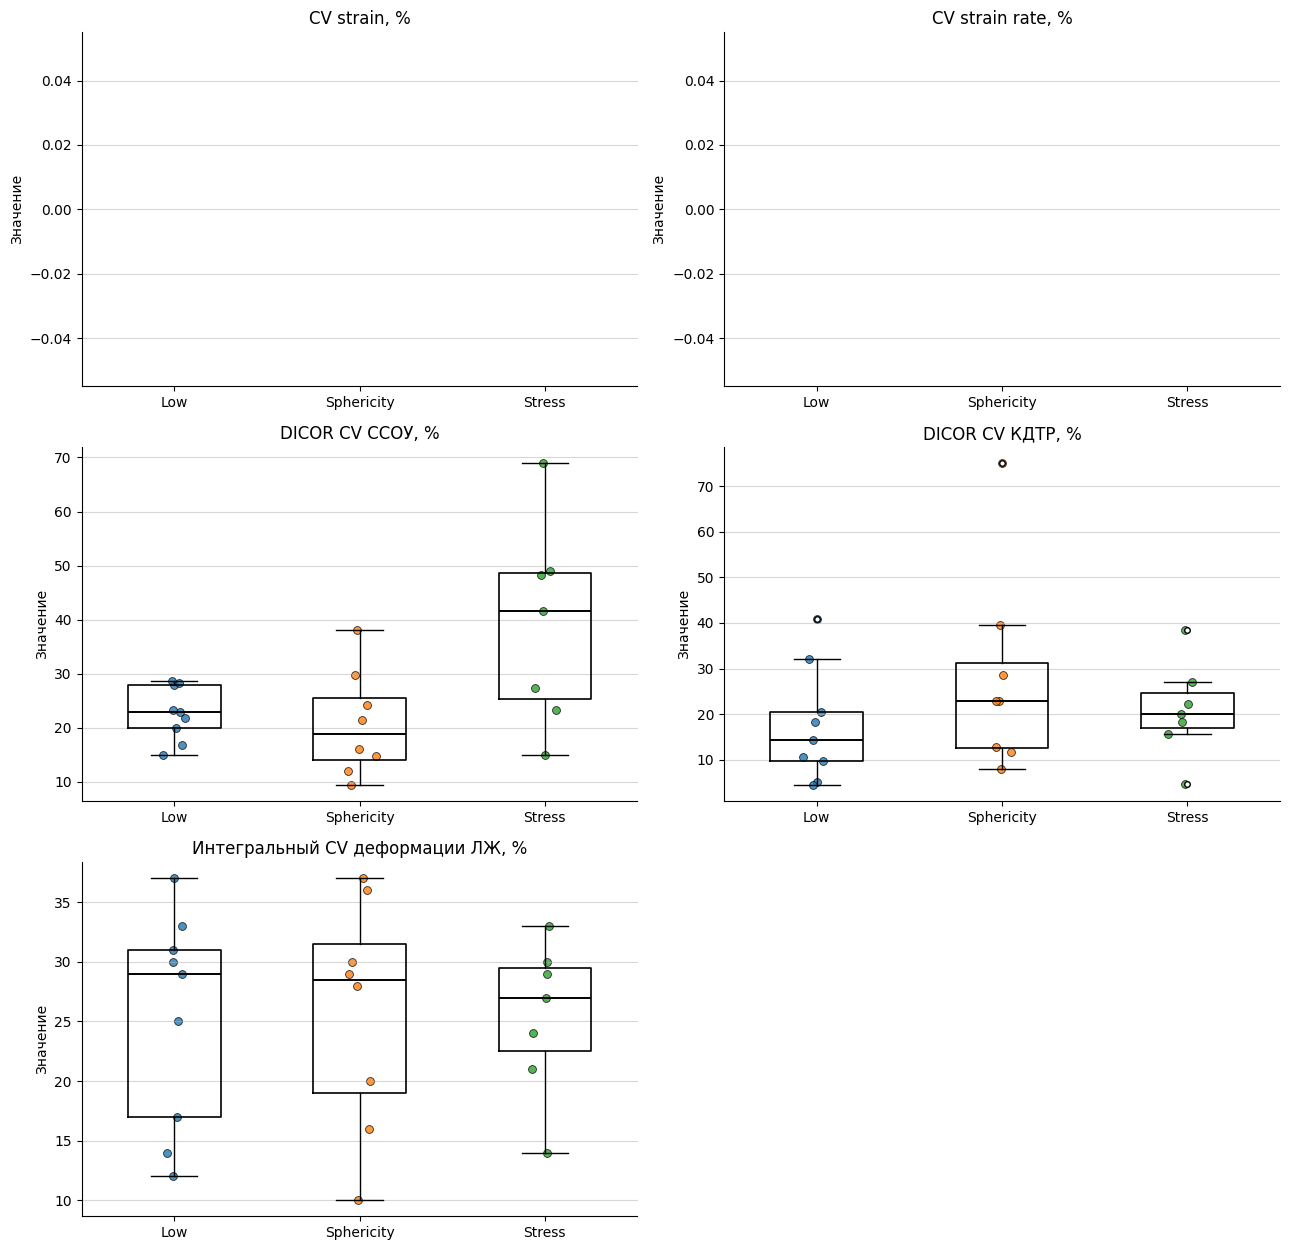

Рисунок сохранён: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\05_chords_adaptation_costs\figures\05_adaptation_cost_by_phenotype_boxplots.png


In [32]:
# ============================================================
# 15. Цена адаптации по фенотипам: strain / DICOR / merged CV
# ============================================================

cost_vars_existing = [
    col for col in adaptation_cost_vars
    if col in main_df.columns
]

print("Переменные цены адаптации:")
for col in cost_vars_existing:
    n = main_df[col].notna().sum()
    print(f"- {col}: n={n}")

n_vars = len(cost_vars_existing)

n_cols = 2
n_rows = int(np.ceil(n_vars / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(13, 4.2 * n_rows)
)

axes = np.array(axes).flatten()

for ax, col in zip(axes, cost_vars_existing):
    data_by_group = [
        main_df.loc[
            main_df["adaptation_phenotype_ru"] == group,
            col
        ].dropna()
        for group in main_phenotype_order_ru
    ]

    ax.boxplot(
        data_by_group,
        patch_artist=False,
        widths=0.5,
        boxprops=dict(color="black", linewidth=1.2),
        medianprops=dict(color="black", linewidth=1.4),
        whiskerprops=dict(color="black", linewidth=1.0),
        capprops=dict(color="black", linewidth=1.0),
        flierprops=dict(
            marker="o",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=4,
        ),
    )

    for i, values in enumerate(data_by_group, start=1):
        jitter = np.random.normal(loc=i, scale=0.035, size=len(values))
        ax.scatter(
            jitter,
            values,
            s=32,
            edgecolor="black",
            linewidth=0.6,
            alpha=0.8,
        )

    ax.set_title(pretty_names.get(col, col))
    ax.set_ylabel("Значение")
    ax.set_xticklabels(["Low", "Sphericity", "Stress"])

    apply_publication_style(ax)

# Убираем пустые оси, если число графиков нечётное
for ax in axes[len(cost_vars_existing):]:
    ax.axis("off")

plt.tight_layout()

fig_path = FIGURES_DIR / "05_adaptation_cost_by_phenotype_boxplots.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Рисунок сохранён:", fig_path)

In [33]:
# ============================================================
# 7. Профиль фенотипов адаптации в исходных единицах
# ============================================================

phenotype_profile_raw = (
    analysis_df
    .dropna(subset=["adaptation_phenotype_ru"])
    .groupby("adaptation_phenotype_ru")[adaptation_vars]
    .agg(["count", "mean", "std", "median", "min", "max"])
)

display(phenotype_profile_raw)

phenotype_profile_raw.to_excel(
    TABLES_DIR / "02_adaptation_phenotype_profiles_raw.xlsx"
)

print("Таблица сохранена:", TABLES_DIR / "02_adaptation_phenotype_profiles_raw.xlsx")

dsws                                          echo_lv_sws_delta_g_cm2                                                             \
                                         count       mean        std median   min   max                   count        mean        std      median         min         max   
adaptation_phenotype_ru                                                                                                                                                      
Геометрически-сферичный фенотип              9  26.444444  10.477489   21.0  14.0  42.0                       9   22.780385  11.353817   21.944419    4.398595   39.878423   
Низконагрузочный менее сферичный фенотип    10  15.400000  11.007068   18.0  -3.0  29.0                      10   12.952005   5.771177   13.480682    3.042909   22.112423   
Стресс-доминантный фенотип                   7  30.285714  10.609968   31.0  12.0  46.0                       7   33.675450   5.080836   35.371669   24.801222   40.536860   
Экстремальный ΔSWS                           1  21.000000        NaN   21.0  21.0  21.0                       1  135.312821        NaN  135.312821  135.312821  135.312821   

                                         echo_lv_sphericity_index_end_systolic_ratio                                          echo_lv_sphericity_index_end_diastolic_ratio  \
                                                                               count      mean       std median    min    max                                        count   
adaptation_phenotype_ru                                                                                                                                                      
Геометрически-сферичный фенотип                                                    9  0.489667  0.044682  0.480  0.438  0.576                                            9   
Низконагрузочный менее сферичный фенотип                                          10  0.388000  0.044422  0.371  0.349  0.487                                           10   
Стресс-доминантный фенотип                                                         7  0.420714  0.050642  0.400  0.373  0.514                                            7   
Экстремальный ΔSWS                                                                 1  0.472000       NaN  0.472  0.472  0.472                                            1   

                                                                                   
                                              mean       std median    min    max  
adaptation_phenotype_ru                                                            
Геометрически-сферичный фенотип           0.551111  0.028989  0.547  0.516  0.602  
Низконагрузочный менее сферичный фенотип  0.465500  0.044142  0.465  0.370  0.535  
Стресс-доминантный фенотип                0.434143  0.048790  0.444  0.343  0.489  
Экстремальный ΔSWS                        0.469000       NaN  0.469  0.469  0.469

Таблица сохранена: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\05_chords_adaptation_costs\tables\02_adaptation_phenotype_profiles_raw.xlsx


,dsws,echo_lv_sws_delta_g_cm2,echo_lv_sphericity_index_end_systolic_ratio,echo_lv_sphericity_index_end_diastolic_ratio
adaptation_phenotype_ru,,,,
Низконагрузочный менее сферичный фенотип,-0.66,-0.80,-0.71,-0.34
Геометрически-сферичный фенотип,0.27,0.08,0.93,1.04
Стресс-доминантный фенотип,0.59,1.05,-0.18,-0.85


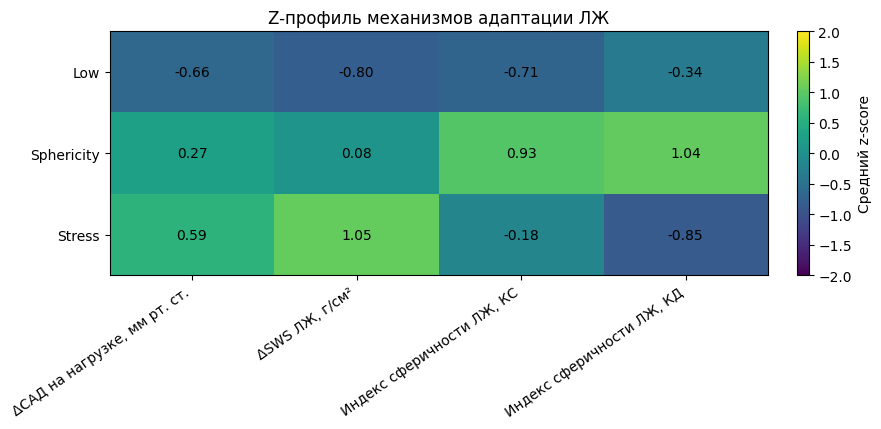

Рисунок сохранён: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\05_chords_adaptation_costs\figures\02_z_profile_adaptation_phenotypes_heatmap.png


In [35]:
# ============================================================
# 9. Heatmap z-профилей трёх основных фенотипов
# ============================================================

# Повторно стандартизируем только основные 3 фенотипа,
# чтобы сравнение было внутри рабочей выборки без экстремального ΔSWS.
scaler_profile = StandardScaler()

X_profile_scaled = pd.DataFrame(
    scaler_profile.fit_transform(main_df[adaptation_vars]),
    columns=adaptation_vars,
    index=main_df.index,
)

X_profile_scaled["adaptation_phenotype_ru"] = main_df["adaptation_phenotype_ru"]

z_profile_main = (
    X_profile_scaled
    .groupby("adaptation_phenotype_ru")[adaptation_vars]
    .mean()
    .reindex(main_phenotype_order_ru)
)

display(z_profile_main.round(2))

fig, ax = plt.subplots(figsize=(9, 4.4))

profile = z_profile_main.copy()
profile.columns = [pretty_names.get(c, c) for c in profile.columns]

im = ax.imshow(profile.values, aspect="auto", vmin=-2, vmax=2)

ax.set_xticks(range(profile.shape[1]))
ax.set_yticks(range(profile.shape[0]))

ax.set_xticklabels(profile.columns, rotation=35, ha="right")
ax.set_yticklabels(["Low", "Sphericity", "Stress"])

for i in range(profile.shape[0]):
    for j in range(profile.shape[1]):
        ax.text(
            j,
            i,
            f"{profile.values[i, j]:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=10,
        )

ax.set_title("Z-профиль механизмов адаптации ЛЖ")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Средний z-score")

plt.tight_layout()

fig_path = FIGURES_DIR / "02_z_profile_adaptation_phenotypes_heatmap.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Рисунок сохранён:", fig_path)

## Промежуточная интерпретация фенотипов адаптации

В дальнейшем анализе используются три основных механико-гемодинамических фенотипа:

1. **Низконагрузочный менее сферичный фенотип**  
   Характеризуется более низкими значениями прироста САД, ΔSWS и индексов сферичности ЛЖ.

2. **Геометрически-сферичный фенотип**  
   Характеризуется более высокими индексами сферичности ЛЖ при умеренной выраженности нагрузочных показателей. Этот вариант можно рассматривать как геометрически-доминантный механизм адаптации.

3. **Стресс-доминантный фенотип**  
   Характеризуется более высоким приростом САД и ΔSWS без выраженной сферизации ЛЖ. Этот вариант можно рассматривать как wall-stress-доминантный механизм адаптации.

Экстремальное наблюдение по ΔSWS сохраняется в данных отдельно, но не включается в основные групповые сравнения, чтобы не искажать интерпретацию малой выборки.

In [36]:
# ============================================================
# 10. Хорды и фенотипы адаптации: таблицы сопряжённости
# ============================================================

categorical_chord_vars = [
    col for col in [
        "Chord_Orientation",
        "Chord_Spread_Class",
        "Chord_Topology_Class",
    ]
    if col in main_df.columns
]

for col in categorical_chord_vars:
    print("=" * 80)
    print(pretty_names.get(col, col))

    ct_counts = pd.crosstab(
        main_df["adaptation_phenotype_ru"],
        main_df[col],
        dropna=False,
    ).reindex(main_phenotype_order_ru)

    ct_pct = pd.crosstab(
        main_df["adaptation_phenotype_ru"],
        main_df[col],
        normalize="index",
        dropna=False,
    ).reindex(main_phenotype_order_ru) * 100

    display(ct_counts)
    display(ct_pct.round(1))

    ct_counts.to_excel(TABLES_DIR / f"03_crosstab_counts_{col}.xlsx")
    ct_pct.round(1).to_excel(TABLES_DIR / f"04_crosstab_pct_{col}.xlsx")

In [41]:
# ============================================================
# Служебная ячейка: стиль графиков
# ============================================================

def apply_publication_style(ax, grid_axis="y"):
    """
    Академический стиль графиков:
    белый фон, черные оси, без верхней и правой рамки.
    """

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_color("black")
    ax.spines["bottom"].set_color("black")

    ax.tick_params(axis="both", colors="black", labelsize=10)

    if grid_axis is not None:
        ax.grid(True, axis=grid_axis, alpha=0.5)

    return ax

In [44]:
# ============================================================
# Диагностика: какие переменные хорд реально есть в main_df
# ============================================================

print("Колонки main_df, связанные с хордами:")

chord_like_cols = [
    col for col in main_df.columns
    if any(term in str(col).lower() for term in [
        "chord",
        "tendon",
        "false",
        "orientation",
        "spread",
        "topology",
    ])
]

for col in chord_like_cols:
    print("-", col)

print("\nТекущий categorical_chord_vars:")
print(categorical_chord_vars if "categorical_chord_vars" in globals() else "categorical_chord_vars ещё не создан")

Колонки main_df, связанные с хордами:
- lv_false_tendon_total_count

Текущий categorical_chord_vars:
[]


In [38]:
# ============================================================
# 12. Статистика: категориальные признаки хорд vs фенотипы
# ============================================================

def cramers_v(confusion_matrix):
    """
    Cramer's V для таблицы сопряжённости.
    """
    chi2, p, dof, expected = stats.chi2_contingency(confusion_matrix)
    n = confusion_matrix.to_numpy().sum()
    r, k = confusion_matrix.shape

    if n == 0:
        return np.nan

    return np.sqrt((chi2 / n) / (min(k - 1, r - 1)))


cat_stats_results = []

for col in categorical_chord_vars:
    ct = pd.crosstab(
        main_df["adaptation_phenotype_ru"],
        main_df[col],
        dropna=False,
    ).reindex(main_phenotype_order_ru)

    chi2, p, dof, expected = stats.chi2_contingency(ct)
    v = cramers_v(ct)

    min_expected = expected.min()

    cat_stats_results.append({
        "variable": col,
        "pretty_name": pretty_names.get(col, col),
        "chi2": chi2,
        "p_value": p,
        "dof": dof,
        "cramers_v": v,
        "min_expected_count": min_expected,
        "note": "Осторожно интерпретировать p-value при малых ожидаемых частотах" if min_expected < 5 else "",
    })

cat_stats_df = pd.DataFrame(cat_stats_results)

display(cat_stats_df)

cat_stats_df.to_excel(
    TABLES_DIR / "05_chord_categorical_stats_vs_phenotype.xlsx",
    index=False,
)

print("Таблица сохранена:", TABLES_DIR / "05_chord_categorical_stats_vs_phenotype.xlsx")

""


Таблица сохранена: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\05_chords_adaptation_costs\tables\05_chord_categorical_stats_vs_phenotype.xlsx


In [39]:
# ============================================================
# 13. Количество хорд по фенотипам адаптации
# ============================================================

count_col = "lv_false_tendon_total_count"

if count_col in main_df.columns:
    count_summary = (
        main_df
        .groupby("adaptation_phenotype_ru")[count_col]
        .agg(["count", "mean", "std", "median", "min", "max"])
        .reindex(main_phenotype_order_ru)
    )

    display(count_summary)

    count_summary.to_excel(TABLES_DIR / "06_chord_count_by_adaptation_phenotype.xlsx")

    # Kruskal-Wallis
    groups = [
        main_df.loc[main_df["adaptation_phenotype_ru"] == group, count_col].dropna()
        for group in main_phenotype_order_ru
    ]

    h_stat, p_value = stats.kruskal(*groups)

    print(f"Kruskal-Wallis H = {h_stat:.3f}, p = {p_value:.4f}")

else:
    print(f"Переменная {count_col} не найдена.")

,count,mean,std,median,min,max
adaptation_phenotype_ru,,,,,,
Низконагрузочный менее сферичный фенотип,9,2.666667,1.414214,2.0,1.0,5.0
Геометрически-сферичный фенотип,8,2.125000,1.246423,2.0,0.0,4.0
Стресс-доминантный фенотип,6,2.333333,1.211060,2.5,1.0,4.0


Kruskal-Wallis H = 0.471, p = 0.7903


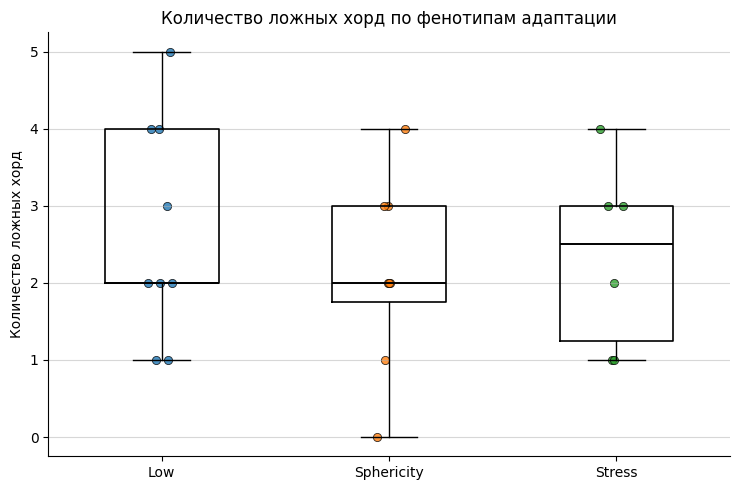

Рисунок сохранён: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\05_chords_adaptation_costs\figures\04_chord_count_by_adaptation_phenotype.png


In [40]:
# ============================================================
# 14. Визуализация количества хорд по фенотипам
# ============================================================

count_col = "lv_false_tendon_total_count"

if count_col in main_df.columns:
    fig, ax = plt.subplots(figsize=(7.5, 5))

    data_by_group = [
        main_df.loc[
            main_df["adaptation_phenotype_ru"] == group,
            count_col
        ].dropna()
        for group in main_phenotype_order_ru
    ]

    ax.boxplot(
        data_by_group,
        patch_artist=False,
        widths=0.5,
        boxprops=dict(color="black", linewidth=1.2),
        medianprops=dict(color="black", linewidth=1.4),
        whiskerprops=dict(color="black", linewidth=1.0),
        capprops=dict(color="black", linewidth=1.0),
        flierprops=dict(
            marker="o",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=4,
        ),
    )

    for i, values in enumerate(data_by_group, start=1):
        jitter = np.random.normal(loc=i, scale=0.035, size=len(values))
        ax.scatter(
            jitter,
            values,
            s=35,
            edgecolor="black",
            linewidth=0.6,
            alpha=0.8,
        )

    ax.set_title("Количество ложных хорд по фенотипам адаптации")
    ax.set_ylabel("Количество ложных хорд")
    ax.set_xticklabels(["Low", "Sphericity", "Stress"])

    apply_publication_style(ax)

    plt.tight_layout()

    fig_path = FIGURES_DIR / "04_chord_count_by_adaptation_phenotype.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Рисунок сохранён:", fig_path)

In [45]:
# ============================================================
# Проверка доступности переменных цены адаптации по фенотипам
# ============================================================

cost_availability = []

for col in adaptation_cost_vars:
    if col not in main_df.columns:
        continue

    for phenotype in main_phenotype_order_ru:
        n = main_df.loc[
            main_df["adaptation_phenotype_ru"] == phenotype,
            col
        ].notna().sum()

        cost_availability.append({
            "variable": col,
            "phenotype": phenotype,
            "n_non_missing": n,
        })

cost_availability_df = pd.DataFrame(cost_availability)

display(cost_availability_df)

,variable,phenotype,n_non_missing
0,echo_lv_strain_plus_cv_pct,Низконагрузочный менее сферичный фенотип,0
1,echo_lv_strain_plus_cv_pct,Геометрически-сферичный фенотип,0
2,echo_lv_strain_plus_cv_pct,Стресс-доминантный фенотип,0
3,echo_lv_strain_rate_cv_pct,Низконагрузочный менее сферичный фенотип,0
4,echo_lv_strain_rate_cv_pct,Геометрически-сферичный фенотип,0
5,echo_lv_strain_rate_cv_pct,Стресс-доминантный фенотип,0
6,dicor_ssou_cv_pct,Низконагрузочный менее сферичный фенотип,9
7,dicor_ssou_cv_pct,Геометрически-сферичный фенотип,8
8,dicor_ssou_cv_pct,Стресс-доминантный фенотип,7
9,dicor_sm_kdtr_cv_pct,Низконагрузочный менее сферичный фенотип,9


In [47]:
# ============================================================
# 18. Пересборка analysis_df после восстановления хордовых переменных
# ============================================================

chord_vars = [
    "lv_false_tendon_total_count",
    "oblique_total",
    "transverse_total",
    "Chord_Orientation",
    "mechanical_chord_phenotype",
]

# оставляем только реально существующие
chord_vars = [col for col in chord_vars if col in df.columns]

analysis_df = df.copy()

analysis_df = analysis_df.join(
    adaptation_phenotypes[
        [
            "adaptation_cluster_k3",
            "adaptation_phenotype",
            "adaptation_phenotype_ru",
        ]
    ],
    how="left",
)

analysis_vars = (
    [
        "adaptation_cluster_k3",
        "adaptation_phenotype",
        "adaptation_phenotype_ru",
    ]
    + adaptation_vars
    + chord_vars
    + adaptation_cost_vars
    + baseline_covariates
)

analysis_vars_existing = [
    col for col in analysis_vars
    if col in analysis_df.columns
]

analysis_df = analysis_df[analysis_vars_existing].copy()

main_df = analysis_df[
    analysis_df["adaptation_phenotype_ru"].isin(main_phenotype_order_ru)
].copy()

print("chord_vars:")
print(chord_vars)

print("\nРазмер analysis_df:", analysis_df.shape)
print("Размер main_df:", main_df.shape)

print("\nРаспределение фенотипов адаптации:")
display(main_df["adaptation_phenotype_ru"].value_counts().reindex(main_phenotype_order_ru))

if "Chord_Orientation" in main_df.columns:
    print("\nРаспределение Chord_Orientation в main_df:")
    display(main_df["Chord_Orientation"].value_counts(dropna=False))

display(main_df.head())

chord_vars:
['lv_false_tendon_total_count', 'oblique_total', 'transverse_total', 'Chord_Orientation', 'mechanical_chord_phenotype']

Размер analysis_df: (153, 18)
Размер main_df: (26, 18)

Распределение фенотипов адаптации:


adaptation_phenotype_ru
Низконагрузочный менее сферичный фенотип    10
Геометрически-сферичный фенотип              9
Стресс-доминантный фенотип                   7
Name: count, dtype: int64


Распределение Chord_Orientation в main_df:


Chord_Orientation
Transverse-Involved    23
Unclassified            2
Oblique-Only            1
Name: count, dtype: int64

,adaptation_cluster_k3,adaptation_phenotype,adaptation_phenotype_ru,dsws,echo_lv_sws_delta_g_cm2,echo_lv_sphericity_index_end_systolic_ratio,echo_lv_sphericity_index_end_diastolic_ratio,lv_false_tendon_total_count,oblique_total,transverse_total,Chord_Orientation,mechanical_chord_phenotype,echo_lv_strain_plus_cv_pct,echo_lv_strain_rate_cv_pct,dicor_ssou_cv_pct,dicor_sm_kdtr_cv_pct,merged_lv_deformation_cv_pct,sex
0,2,Stress-dominant phenotype,Стресс-доминантный фенотип,37.0,35.371669,0.463,0.343,1.0,4.0,1.0,Transverse-Involved,Transverse-Involved,NaN,NaN,27.282681,15.713484,24.0,1.0
2,0,Sphericity-dominant phenotype,Геометрически-сферичный фенотип,42.0,38.579679,0.505,0.602,4.0,2.0,5.0,Transverse-Involved,Transverse-Involved,NaN,NaN,16.148942,28.571429,37.0,1.0
3,2,Stress-dominant phenotype,Стресс-доминантный фенотип,46.0,40.536860,0.514,0.400,3.0,1.0,6.0,Transverse-Involved,Transverse-Involved,NaN,NaN,41.583903,4.651163,33.0,1.0
4,0,Sphericity-dominant phenotype,Геометрически-сферичный фенотип,21.0,26.281070,0.576,0.530,3.0,0.0,0.0,Unclassified,Unclassified,NaN,NaN,NaN,NaN,NaN,1.0
5,1,Low load / low sphericity phenotype,Низконагрузочный менее сферичный фенотип,21.0,22.112423,0.365,0.462,4.0,1.0,7.0,Transverse-Involved,Transverse-Involved,NaN,NaN,27.952038,5.128205,30.0,1.0


In [48]:
# ============================================================
# 19. Chord_Orientation по фенотипам адаптации
# ============================================================

if "Chord_Orientation" not in main_df.columns:
    print("Chord_Orientation не найдена в main_df.")
else:
    orientation_df = main_df[
        main_df["Chord_Orientation"].isin([
            "Oblique-Only",
            "Transverse-Involved",
        ])
    ].copy()

    print("Размер orientation_df:", orientation_df.shape)

    orientation_counts = pd.crosstab(
        orientation_df["adaptation_phenotype_ru"],
        orientation_df["Chord_Orientation"],
    ).reindex(main_phenotype_order_ru)

    orientation_pct = pd.crosstab(
        orientation_df["adaptation_phenotype_ru"],
        orientation_df["Chord_Orientation"],
        normalize="index",
    ).reindex(main_phenotype_order_ru) * 100

    print("Количество:")
    display(orientation_counts)

    print("Доли внутри фенотипа, %:")
    display(orientation_pct.round(1))

    orientation_counts.to_excel(TABLES_DIR / "08_chord_orientation_by_adaptation_counts.xlsx")
    orientation_pct.round(1).to_excel(TABLES_DIR / "09_chord_orientation_by_adaptation_pct.xlsx")

Размер orientation_df: (24, 18)
Количество:


Chord_Orientation,Oblique-Only,Transverse-Involved
adaptation_phenotype_ru,,
Низконагрузочный менее сферичный фенотип,1,8
Геометрически-сферичный фенотип,0,8
Стресс-доминантный фенотип,0,7


Доли внутри фенотипа, %:


Chord_Orientation,Oblique-Only,Transverse-Involved
adaptation_phenotype_ru,,
Низконагрузочный менее сферичный фенотип,11.1,88.9
Геометрически-сферичный фенотип,0.0,100.0
Стресс-доминантный фенотип,0.0,100.0


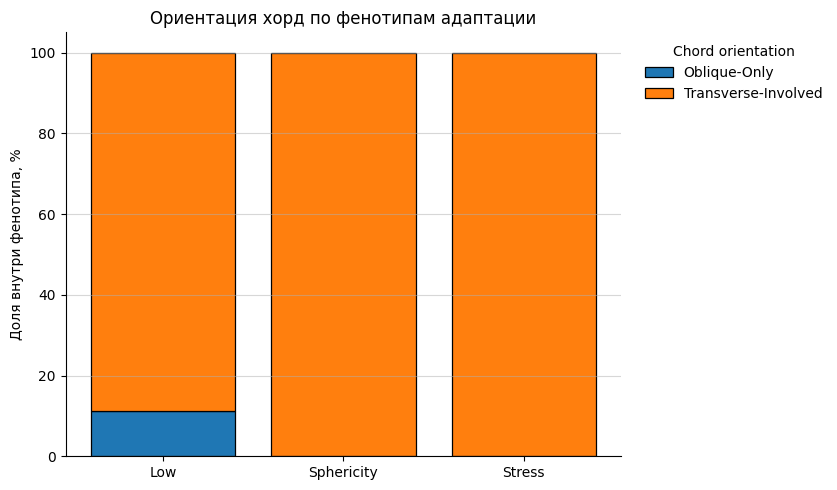

Рисунок сохранён: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\05_chords_adaptation_costs\figures\06_chord_orientation_by_adaptation_phenotype.png


In [49]:
# ============================================================
# 20. Визуализация Chord_Orientation по фенотипам адаптации
# ============================================================

if "Chord_Orientation" not in main_df.columns:
    print("Chord_Orientation не найдена в main_df.")
else:
    orientation_df = main_df[
        main_df["Chord_Orientation"].isin([
            "Oblique-Only",
            "Transverse-Involved",
        ])
    ].copy()

    orientation_pct = pd.crosstab(
        orientation_df["adaptation_phenotype_ru"],
        orientation_df["Chord_Orientation"],
        normalize="index",
    ).reindex(main_phenotype_order_ru) * 100

    fig, ax = plt.subplots(figsize=(8.5, 5))

    x = np.arange(len(orientation_pct.index))
    bottom = np.zeros(len(orientation_pct.index))

    for category in orientation_pct.columns:
        values = orientation_pct[category].fillna(0).values

        ax.bar(
            x,
            values,
            bottom=bottom,
            edgecolor="black",
            linewidth=0.9,
            label=str(category),
        )

        bottom += values

    ax.set_title("Ориентация хорд по фенотипам адаптации")
    ax.set_ylabel("Доля внутри фенотипа, %")
    ax.set_xticks(x)
    ax.set_xticklabels(["Low", "Sphericity", "Stress"])

    ax.legend(
        frameon=False,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        title="Chord orientation",
    )

    apply_publication_style(ax)

    plt.tight_layout()

    fig_path = FIGURES_DIR / "06_chord_orientation_by_adaptation_phenotype.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Рисунок сохранён:", fig_path)

In [50]:
# ============================================================
# 21. Статистика: Chord_Orientation vs фенотип адаптации
# ============================================================

def cramers_v(confusion_matrix):
    chi2, p, dof, expected = stats.chi2_contingency(confusion_matrix)

    n = confusion_matrix.to_numpy().sum()
    r, k = confusion_matrix.shape

    if n == 0:
        return np.nan

    return np.sqrt((chi2 / n) / (min(k - 1, r - 1)))


if "Chord_Orientation" not in main_df.columns:
    print("Chord_Orientation не найдена в main_df.")
else:
    orientation_df = main_df[
        main_df["Chord_Orientation"].isin([
            "Oblique-Only",
            "Transverse-Involved",
        ])
    ].copy()

    orientation_counts = pd.crosstab(
        orientation_df["adaptation_phenotype_ru"],
        orientation_df["Chord_Orientation"],
    ).reindex(main_phenotype_order_ru)

    chi2, p_value, dof, expected = stats.chi2_contingency(orientation_counts)
    v = cramers_v(orientation_counts)

    print("Chi-square test")
    print("chi2:", round(chi2, 3))
    print("p-value:", round(p_value, 4))
    print("dof:", dof)
    print("Cramer's V:", round(v, 3))
    print("Минимальная ожидаемая частота:", round(expected.min(), 2))

    if expected.min() < 5:
        print("\nВажно: ожидаемые частоты маленькие, поэтому p-value интерпретировать осторожно.")
        print("В этой задаче важнее смотреть на направление эффекта и Cramer's V.")

Chi-square test
chi2: 1.739
p-value: 0.4191
dof: 2
Cramer's V: 0.269
Минимальная ожидаемая частота: 0.29

Важно: ожидаемые частоты маленькие, поэтому p-value интерпретировать осторожно.
В этой задаче важнее смотреть на направление эффекта и Cramer's V.


Доступные переменные цены адаптации:
- dicor_ssou_cv_pct n = 24
- dicor_sm_kdtr_cv_pct n = 24
- merged_lv_deformation_cv_pct n = 24


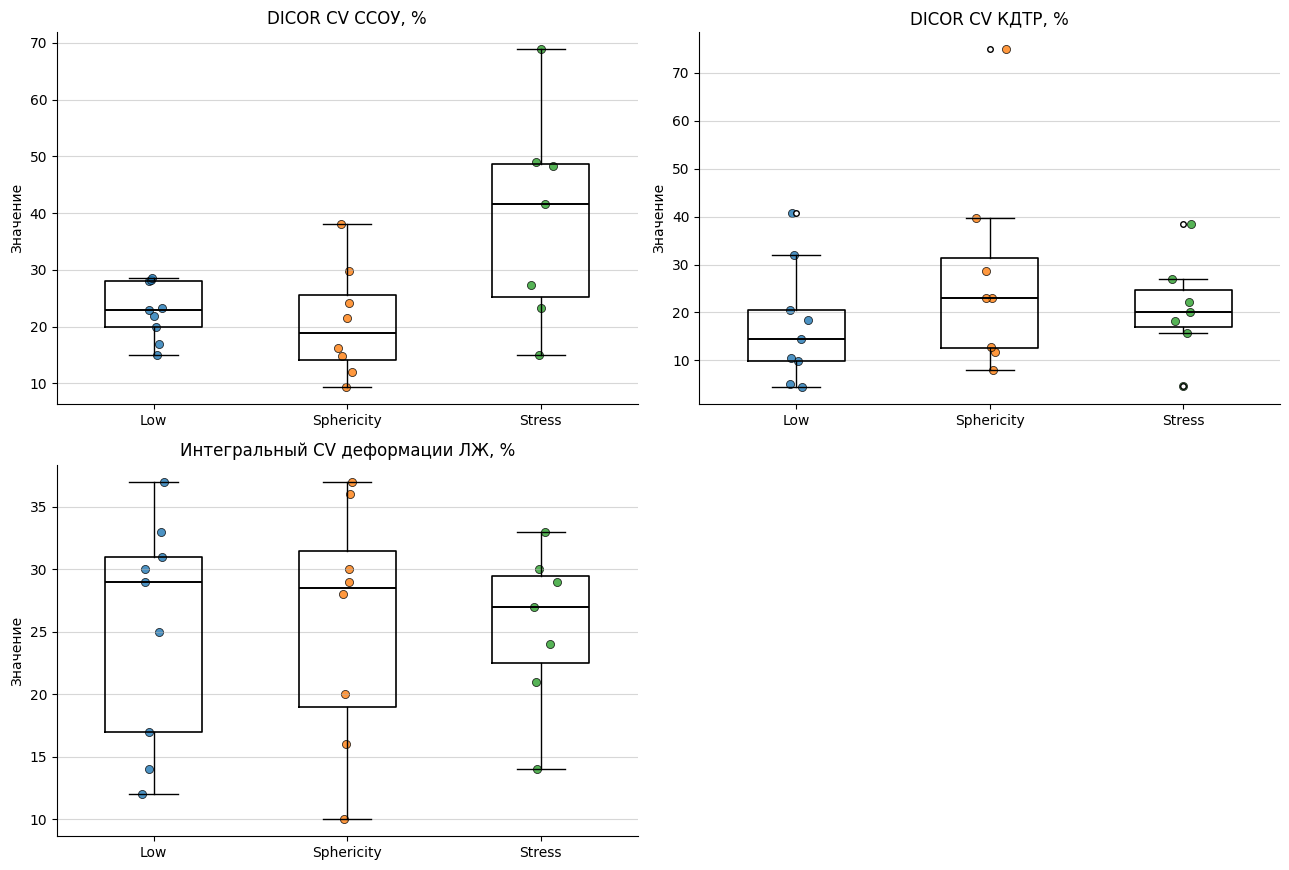

Рисунок сохранён: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\05_chords_adaptation_costs\figures\07_available_adaptation_cost_by_phenotype.png


In [51]:
# ============================================================
# 22. Цена адаптации: только доступные переменные
# ============================================================

available_cost_vars = []

for col in adaptation_cost_vars:
    if col in main_df.columns and main_df[col].notna().sum() > 0:
        available_cost_vars.append(col)

print("Доступные переменные цены адаптации:")
for col in available_cost_vars:
    print("-", col, "n =", main_df[col].notna().sum())

n_vars = len(available_cost_vars)

n_cols = 2
n_rows = int(np.ceil(n_vars / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(13, 4.4 * n_rows),
)

axes = np.array(axes).flatten()

for ax, col in zip(axes, available_cost_vars):
    data_by_group = [
        main_df.loc[
            main_df["adaptation_phenotype_ru"] == group,
            col,
        ].dropna()
        for group in main_phenotype_order_ru
    ]

    ax.boxplot(
        data_by_group,
        patch_artist=False,
        widths=0.5,
        boxprops=dict(color="black", linewidth=1.2),
        medianprops=dict(color="black", linewidth=1.4),
        whiskerprops=dict(color="black", linewidth=1.0),
        capprops=dict(color="black", linewidth=1.0),
        flierprops=dict(
            marker="o",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=4,
        ),
    )

    for i, values in enumerate(data_by_group, start=1):
        jitter = np.random.normal(loc=i, scale=0.035, size=len(values))
        ax.scatter(
            jitter,
            values,
            s=34,
            edgecolor="black",
            linewidth=0.6,
            alpha=0.8,
        )

    ax.set_title(pretty_names.get(col, col))
    ax.set_ylabel("Значение")
    ax.set_xticklabels(["Low", "Sphericity", "Stress"])

    apply_publication_style(ax)

for ax in axes[len(available_cost_vars):]:
    ax.axis("off")

plt.tight_layout()

fig_path = FIGURES_DIR / "07_available_adaptation_cost_by_phenotype.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Рисунок сохранён:", fig_path)

In [52]:


# ============================================================
# 23. Доступные переменные цены адаптации
# ============================================================

cost_vars_candidate = [
    "echo_lv_strain_plus_cv_pct",
    "echo_lv_strain_rate_cv_pct",
    "dicor_ssou_cv_pct",
    "dicor_sm_kdtr_cv_pct",
    "merged_lv_deformation_cv_pct",
]

cost_availability = []

for col in cost_vars_candidate:
    if col not in main_df.columns:
        continue

    for phenotype in main_phenotype_order_ru:
        n = main_df.loc[
            main_df["adaptation_phenotype_ru"] == phenotype,
            col
        ].notna().sum()

        cost_availability.append({
            "variable": col,
            "pretty_name": pretty_names.get(col, col),
            "phenotype": phenotype,
            "n_non_missing": n,
        })

cost_availability_df = pd.DataFrame(cost_availability)

display(cost_availability_df)

# Оставляем только переменные, где есть хотя бы 3 наблюдения в каждом фенотипе
available_cost_vars = []

for col in cost_vars_candidate:
    if col not in main_df.columns:
        continue

    group_ns = [
        main_df.loc[
            main_df["adaptation_phenotype_ru"] == phenotype,
            col
        ].notna().sum()
        for phenotype in main_phenotype_order_ru
    ]

    if min(group_ns) >= 3:
        available_cost_vars.append(col)

print("\nПеременные, пригодные для анализа цены адаптации:")
for col in available_cost_vars:
    print("-", col, "|", pretty_names.get(col, col))

,variable,pretty_name,phenotype,n_non_missing
0,echo_lv_strain_plus_cv_pct,"CV strain, %",Низконагрузочный менее сферичный фенотип,0
1,echo_lv_strain_plus_cv_pct,"CV strain, %",Геометрически-сферичный фенотип,0
2,echo_lv_strain_plus_cv_pct,"CV strain, %",Стресс-доминантный фенотип,0
3,echo_lv_strain_rate_cv_pct,"CV strain rate, %",Низконагрузочный менее сферичный фенотип,0
4,echo_lv_strain_rate_cv_pct,"CV strain rate, %",Геометрически-сферичный фенотип,0
5,echo_lv_strain_rate_cv_pct,"CV strain rate, %",Стресс-доминантный фенотип,0
6,dicor_ssou_cv_pct,"DICOR CV ССОУ, %",Низконагрузочный менее сферичный фенотип,9
7,dicor_ssou_cv_pct,"DICOR CV ССОУ, %",Геометрически-сферичный фенотип,8
8,dicor_ssou_cv_pct,"DICOR CV ССОУ, %",Стресс-доминантный фенотип,7
9,dicor_sm_kdtr_cv_pct,"DICOR CV КДТР, %",Низконагрузочный менее сферичный фенотип,9



Переменные, пригодные для анализа цены адаптации:
- dicor_ssou_cv_pct | DICOR CV ССОУ, %
- dicor_sm_kdtr_cv_pct | DICOR CV КДТР, %
- merged_lv_deformation_cv_pct | Интегральный CV деформации ЛЖ, %


In [53]:
# ============================================================
# 24. Описательная статистика цены адаптации по фенотипам
# ============================================================

cost_summary = (
    main_df
    .groupby("adaptation_phenotype_ru")[available_cost_vars]
    .agg(["count", "mean", "std", "median", "min", "max"])
    .reindex(main_phenotype_order_ru)
)

display(cost_summary)

cost_summary.to_excel(
    TABLES_DIR / "10_adaptation_cost_summary_by_phenotype.xlsx"
)

print("Таблица сохранена:", TABLES_DIR / "10_adaptation_cost_summary_by_phenotype.xlsx")

dicor_ssou_cv_pct                                                        dicor_sm_kdtr_cv_pct                                             \
                                                     count       mean        std     median        min        max                count       mean        std     median       min   
adaptation_phenotype_ru                                                                                                                                                             
Низконагрузочный менее сферичный фенотип                 9  22.729629   4.937919  22.873937  14.999743  28.577299                    9  17.329600  12.276168  14.380637  4.444444   
Геометрически-сферичный фенотип                          8  20.712986   9.687897  18.788777   9.367687  38.083756                    8  27.704942  21.663603  22.945084  8.000000   
Стресс-доминантный фенотип                               7  39.021039  18.498417  41.583903  14.922640  68.894873                    7  20.924945  10.384205  20.156360  4.651163   

                                                    merged_lv_deformation_cv_pct                                          
                                                max                        count       mean       std median   min   max  
adaptation_phenotype_ru                                                                                                   
Низконагрузочный менее сферичный фенотип  40.809916                            9  25.333333  8.930286   29.0  12.0  37.0  
Геометрически-сферичный фенотип           74.965557                            8  25.750000  9.573028   28.5  10.0  37.0  
Стресс-доминантный фенотип                38.490018                            7  25.428571  6.399405   27.0  14.0  33.0

Таблица сохранена: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\05_chords_adaptation_costs\tables\10_adaptation_cost_summary_by_phenotype.xlsx


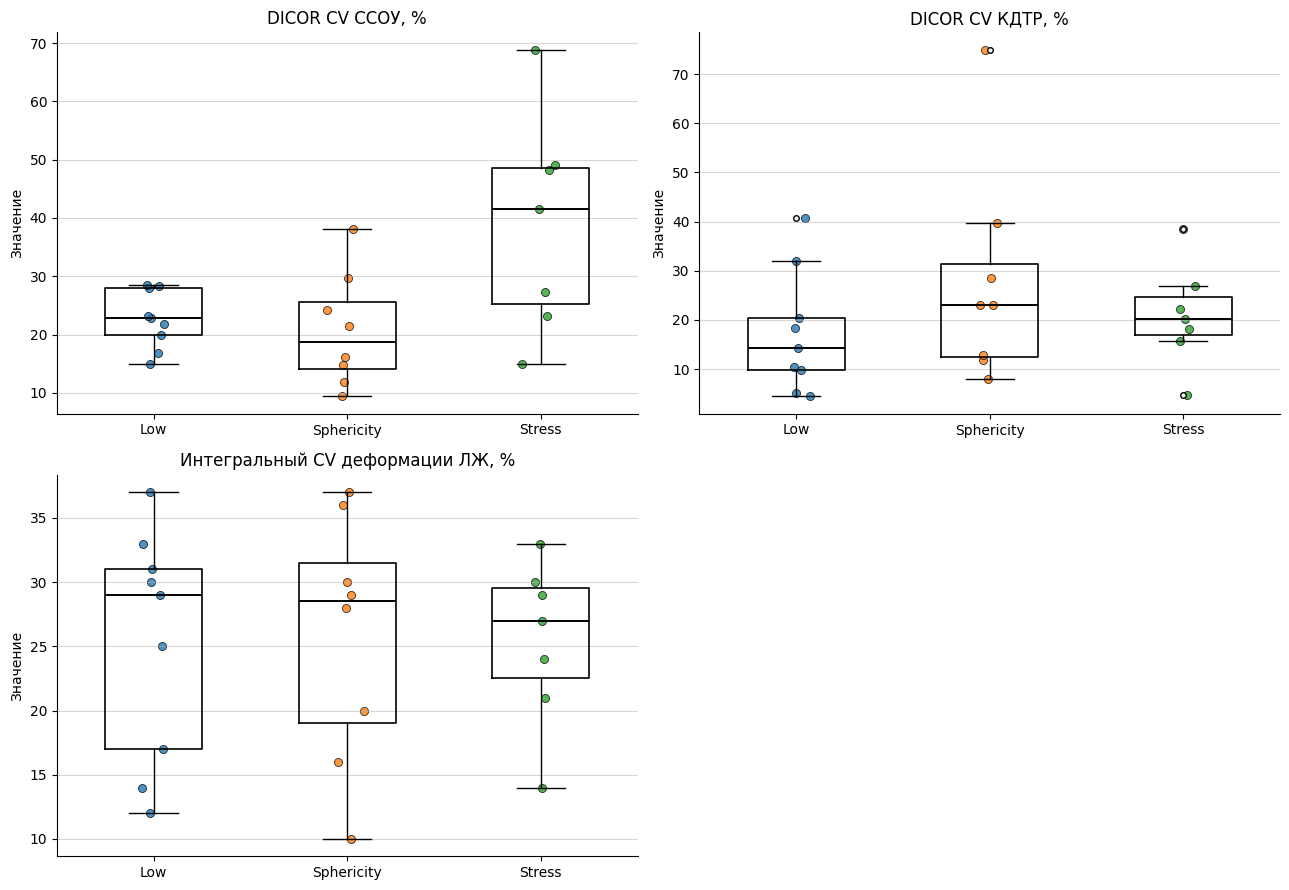

Рисунок сохранён: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\05_chords_adaptation_costs\figures\08_adaptation_cost_by_phenotype_boxplots.png


In [54]:
# ============================================================
# 25. Визуализация цены адаптации по фенотипам
# ============================================================

n_vars = len(available_cost_vars)

n_cols = 2
n_rows = int(np.ceil(n_vars / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(13, 4.5 * n_rows)
)

axes = np.array(axes).flatten()

for ax, col in zip(axes, available_cost_vars):
    data_by_group = [
        main_df.loc[
            main_df["adaptation_phenotype_ru"] == phenotype,
            col
        ].dropna()
        for phenotype in main_phenotype_order_ru
    ]

    ax.boxplot(
        data_by_group,
        patch_artist=False,
        widths=0.5,
        boxprops=dict(color="black", linewidth=1.2),
        medianprops=dict(color="black", linewidth=1.4),
        whiskerprops=dict(color="black", linewidth=1.0),
        capprops=dict(color="black", linewidth=1.0),
        flierprops=dict(
            marker="o",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=4,
        ),
    )

    for i, values in enumerate(data_by_group, start=1):
        jitter = np.random.normal(loc=i, scale=0.035, size=len(values))

        ax.scatter(
            jitter,
            values,
            s=34,
            edgecolor="black",
            linewidth=0.6,
            alpha=0.8,
        )

    ax.set_title(pretty_names.get(col, col))
    ax.set_ylabel("Значение")
    ax.set_xticklabels(["Low", "Sphericity", "Stress"])

    apply_publication_style(ax)

for ax in axes[len(available_cost_vars):]:
    ax.axis("off")

plt.tight_layout()

fig_path = FIGURES_DIR / "08_adaptation_cost_by_phenotype_boxplots.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Рисунок сохранён:", fig_path)

In [55]:
# ============================================================
# 26. Kruskal-Wallis: цена адаптации vs фенотип адаптации
# ============================================================

kruskal_results = []

for col in available_cost_vars:
    groups = [
        main_df.loc[
            main_df["adaptation_phenotype_ru"] == phenotype,
            col
        ].dropna()
        for phenotype in main_phenotype_order_ru
    ]

    h_stat, p_value = stats.kruskal(*groups)

    kruskal_results.append({
        "variable": col,
        "pretty_name": pretty_names.get(col, col),
        "H": h_stat,
        "p_value": p_value,
        "n_low": len(groups[0]),
        "n_sphericity": len(groups[1]),
        "n_stress": len(groups[2]),
        "median_low": np.median(groups[0]),
        "median_sphericity": np.median(groups[1]),
        "median_stress": np.median(groups[2]),
    })

kruskal_results_df = pd.DataFrame(kruskal_results)

display(kruskal_results_df)

kruskal_results_df.to_excel(
    TABLES_DIR / "11_kruskal_adaptation_cost_by_phenotype.xlsx",
    index=False
)

print("Таблица сохранена:", TABLES_DIR / "11_kruskal_adaptation_cost_by_phenotype.xlsx")

,variable,pretty_name,H,p_value,n_low,n_sphericity,n_stress,median_low,median_sphericity,median_stress
0,dicor_ssou_cv_pct,"DICOR CV ССОУ, %",5.251270,0.072394,9,8,7,22.873937,18.788777,41.583903
1,dicor_sm_kdtr_cv_pct,"DICOR CV КДТР, %",1.586047,0.452475,9,8,7,14.380637,22.945084,20.156360
2,merged_lv_deformation_cv_pct,"Интегральный CV деформации ЛЖ, %",0.083883,0.958926,9,8,7,29.000000,28.500000,27.000000


Таблица сохранена: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\05_chords_adaptation_costs\tables\11_kruskal_adaptation_cost_by_phenotype.xlsx


In [56]:
# ============================================================
# 27. Pairwise Mann-Whitney + Cliff's delta
# ============================================================

def cliffs_delta(x, y):
    """
    Cliff's delta:
    +1 означает, что значения в x почти всегда выше y;
    -1 означает, что значения в x почти всегда ниже y;
     0 означает отсутствие направленного различия.
    """
    x = np.asarray(x)
    y = np.asarray(y)

    x = x[~np.isnan(x)]
    y = y[~np.isnan(y)]

    if len(x) == 0 or len(y) == 0:
        return np.nan

    n_greater = 0
    n_less = 0

    for xi in x:
        n_greater += np.sum(xi > y)
        n_less += np.sum(xi < y)

    return (n_greater - n_less) / (len(x) * len(y))


pairwise_results = []

phenotype_pairs = [
    (
        "Низконагрузочный менее сферичный фенотип",
        "Геометрически-сферичный фенотип",
        "Low vs Sphericity",
    ),
    (
        "Низконагрузочный менее сферичный фенотип",
        "Стресс-доминантный фенотип",
        "Low vs Stress",
    ),
    (
        "Геометрически-сферичный фенотип",
        "Стресс-доминантный фенотип",
        "Sphericity vs Stress",
    ),
]

for col in available_cost_vars:
    for group_a, group_b, comparison_name in phenotype_pairs:
        x = main_df.loc[
            main_df["adaptation_phenotype_ru"] == group_a,
            col
        ].dropna()

        y = main_df.loc[
            main_df["adaptation_phenotype_ru"] == group_b,
            col
        ].dropna()

        u_stat, p_value = stats.mannwhitneyu(
            x,
            y,
            alternative="two-sided"
        )

        delta = cliffs_delta(x, y)

        pairwise_results.append({
            "variable": col,
            "pretty_name": pretty_names.get(col, col),
            "comparison": comparison_name,
            "n_group_a": len(x),
            "n_group_b": len(y),
            "median_group_a": np.median(x),
            "median_group_b": np.median(y),
            "mannwhitney_u": u_stat,
            "p_value": p_value,
            "cliffs_delta_group_a_vs_group_b": delta,
        })

pairwise_results_df = pd.DataFrame(pairwise_results)

display(pairwise_results_df)

pairwise_results_df.to_excel(
    TABLES_DIR / "12_pairwise_adaptation_cost_by_phenotype.xlsx",
    index=False
)

print("Таблица сохранена:", TABLES_DIR / "12_pairwise_adaptation_cost_by_phenotype.xlsx")

,variable,pretty_name,comparison,n_group_a,n_group_b,median_group_a,median_group_b,mannwhitney_u,p_value,cliffs_delta_group_a_vs_group_b
0,dicor_ssou_cv_pct,"DICOR CV ССОУ, %",Low vs Sphericity,9,8,22.873937,18.788777,44.0,0.480708,0.222222
1,dicor_ssou_cv_pct,"DICOR CV ССОУ, %",Low vs Stress,9,7,22.873937,41.583903,15.0,0.090734,-0.523810
2,dicor_ssou_cv_pct,"DICOR CV ССОУ, %",Sphericity vs Stress,8,7,18.788777,41.583903,10.0,0.040093,-0.642857
3,dicor_sm_kdtr_cv_pct,"DICOR CV КДТР, %",Low vs Sphericity,9,8,14.380637,22.945084,24.0,0.268179,-0.333333
4,dicor_sm_kdtr_cv_pct,"DICOR CV КДТР, %",Low vs Stress,9,7,14.380637,20.156360,24.0,0.469755,-0.238095
5,dicor_sm_kdtr_cv_pct,"DICOR CV КДТР, %",Sphericity vs Stress,8,7,22.945084,20.156360,33.0,0.602200,0.178571
6,merged_lv_deformation_cv_pct,"Интегральный CV деформации ЛЖ, %",Low vs Sphericity,9,8,29.000000,28.500000,36.5,1.000000,0.013889
7,merged_lv_deformation_cv_pct,"Интегральный CV деформации ЛЖ, %",Low vs Stress,9,7,29.000000,27.000000,34.0,0.831851,0.079365
8,merged_lv_deformation_cv_pct,"Интегральный CV деформации ЛЖ, %",Sphericity vs Stress,8,7,28.500000,27.000000,30.0,0.861942,0.071429


Таблица сохранена: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\05_chords_adaptation_costs\tables\12_pairwise_adaptation_cost_by_phenotype.xlsx


In [57]:
# ============================================================
# 28. Фокус-гипотеза: Stress phenotype vs остальные фенотипы
# ============================================================

stress_vs_other_results = []

stress_label = "Стресс-доминантный фенотип"

for col in available_cost_vars:
    stress_values = main_df.loc[
        main_df["adaptation_phenotype_ru"] == stress_label,
        col
    ].dropna()

    other_values = main_df.loc[
        main_df["adaptation_phenotype_ru"] != stress_label,
        col
    ].dropna()

    u_stat, p_value = stats.mannwhitneyu(
        stress_values,
        other_values,
        alternative="two-sided"
    )

    delta = cliffs_delta(stress_values, other_values)

    stress_vs_other_results.append({
        "variable": col,
        "pretty_name": pretty_names.get(col, col),
        "n_stress": len(stress_values),
        "n_other": len(other_values),
        "median_stress": np.median(stress_values),
        "median_other": np.median(other_values),
        "mean_stress": np.mean(stress_values),
        "mean_other": np.mean(other_values),
        "mannwhitney_u": u_stat,
        "p_value": p_value,
        "cliffs_delta_stress_vs_other": delta,
    })

stress_vs_other_df = pd.DataFrame(stress_vs_other_results)

display(stress_vs_other_df)

stress_vs_other_df.to_excel(
    TABLES_DIR / "13_stress_vs_other_adaptation_cost.xlsx",
    index=False
)

print("Таблица сохранена:", TABLES_DIR / "13_stress_vs_other_adaptation_cost.xlsx")

,variable,pretty_name,n_stress,n_other,median_stress,median_other,mean_stress,mean_other,mannwhitney_u,p_value,cliffs_delta_stress_vs_other
0,dicor_ssou_cv_pct,"DICOR CV ССОУ, %",7,17,41.583903,21.830729,39.021039,21.780621,94.0,0.028263,0.579832
1,dicor_sm_kdtr_cv_pct,"DICOR CV КДТР, %",7,17,20.156360,18.324914,20.924945,22.212114,62.0,0.898902,0.042017
2,merged_lv_deformation_cv_pct,"Интегральный CV деформации ЛЖ, %",7,17,27.000000,29.000000,25.428571,25.529412,55.0,0.798991,-0.075630


Таблица сохранена: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\05_chords_adaptation_costs\tables\13_stress_vs_other_adaptation_cost.xlsx


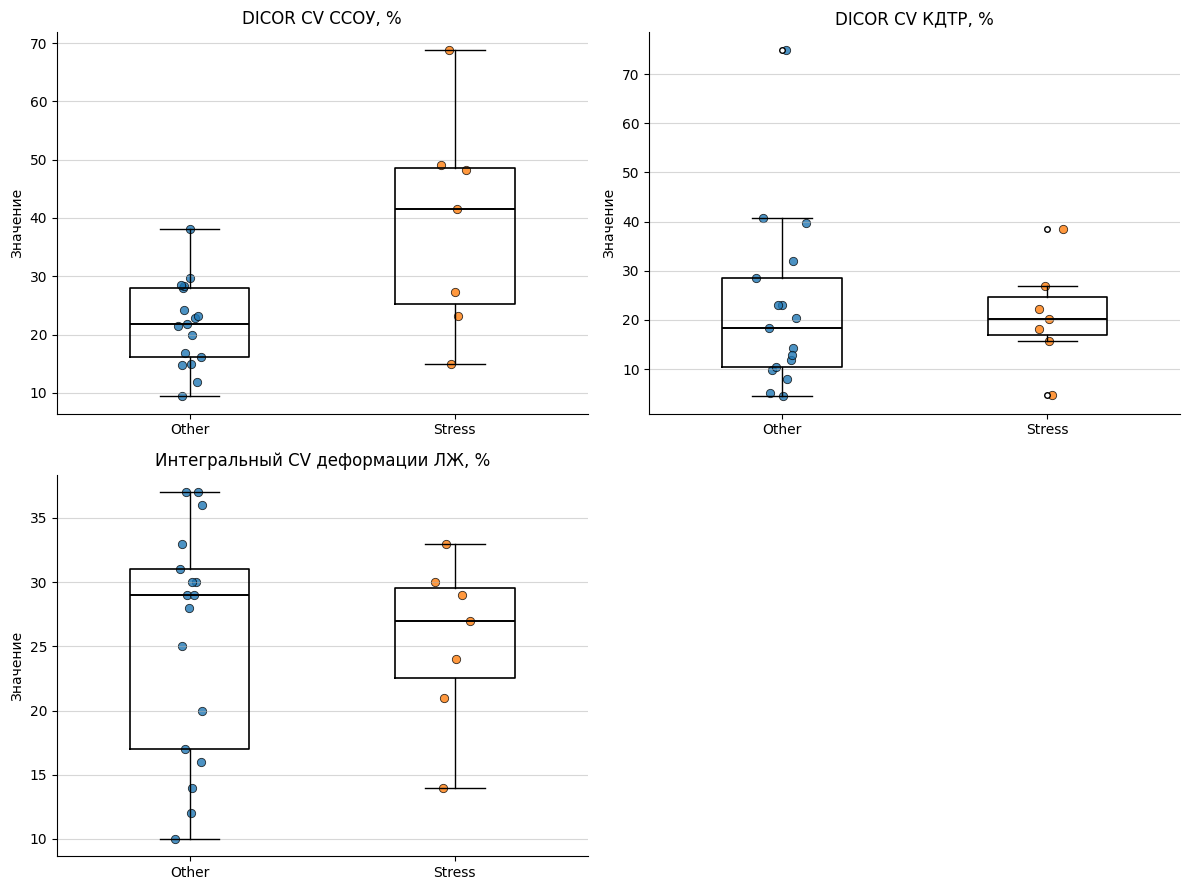

Рисунок сохранён: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\05_chords_adaptation_costs\figures\09_stress_vs_other_adaptation_cost_boxplots.png


In [58]:
# ============================================================
# 29. Визуализация: Stress phenotype vs остальные
# ============================================================

plot_df = main_df.copy()

plot_df["stress_group"] = np.where(
    plot_df["adaptation_phenotype_ru"] == "Стресс-доминантный фенотип",
    "Stress",
    "Other"
)

stress_group_order = ["Other", "Stress"]

n_vars = len(available_cost_vars)
n_cols = 2
n_rows = int(np.ceil(n_vars / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(12, 4.5 * n_rows)
)

axes = np.array(axes).flatten()

for ax, col in zip(axes, available_cost_vars):
    data_by_group = [
        plot_df.loc[
            plot_df["stress_group"] == group,
            col
        ].dropna()
        for group in stress_group_order
    ]

    ax.boxplot(
        data_by_group,
        patch_artist=False,
        widths=0.45,
        boxprops=dict(color="black", linewidth=1.2),
        medianprops=dict(color="black", linewidth=1.4),
        whiskerprops=dict(color="black", linewidth=1.0),
        capprops=dict(color="black", linewidth=1.0),
        flierprops=dict(
            marker="o",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=4,
        ),
    )

    for i, values in enumerate(data_by_group, start=1):
        jitter = np.random.normal(loc=i, scale=0.035, size=len(values))

        ax.scatter(
            jitter,
            values,
            s=36,
            edgecolor="black",
            linewidth=0.6,
            alpha=0.8,
        )

    ax.set_title(pretty_names.get(col, col))
    ax.set_ylabel("Значение")
    ax.set_xticklabels(stress_group_order)

    apply_publication_style(ax)

for ax in axes[len(available_cost_vars):]:
    ax.axis("off")

plt.tight_layout()

fig_path = FIGURES_DIR / "09_stress_vs_other_adaptation_cost_boxplots.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Рисунок сохранён:", fig_path)

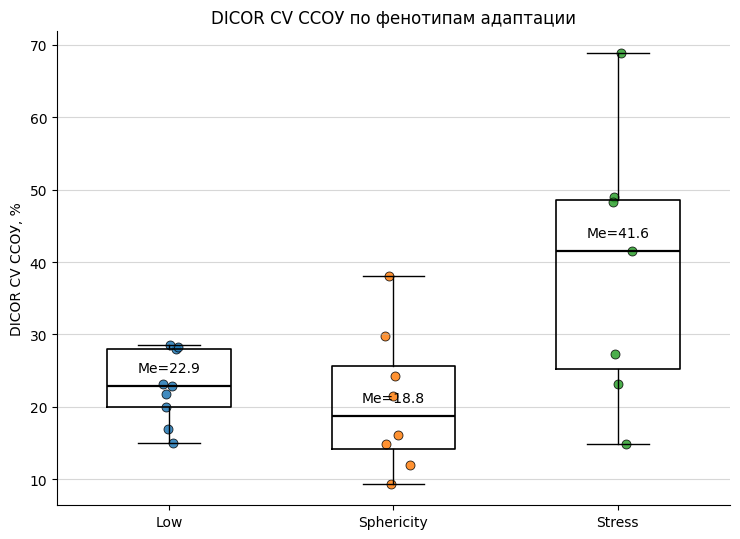

Рисунок сохранён: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\05_chords_adaptation_costs\figures\10_focus_dicor_ssou_by_phenotype.png


In [59]:
# ============================================================
# 30. Фокус-график: DICOR CV ССОУ по фенотипам адаптации
# ============================================================

focus_var = "dicor_ssou_cv_pct"

fig, ax = plt.subplots(figsize=(7.5, 5.5))

data_by_group = [
    main_df.loc[
        main_df["adaptation_phenotype_ru"] == phenotype,
        focus_var
    ].dropna()
    for phenotype in main_phenotype_order_ru
]

ax.boxplot(
    data_by_group,
    patch_artist=False,
    widths=0.55,
    boxprops=dict(color="black", linewidth=1.2),
    medianprops=dict(color="black", linewidth=1.6),
    whiskerprops=dict(color="black", linewidth=1.0),
    capprops=dict(color="black", linewidth=1.0),
    flierprops=dict(
        marker="o",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=4,
    ),
)

for i, values in enumerate(data_by_group, start=1):
    jitter = np.random.normal(loc=i, scale=0.04, size=len(values))
    ax.scatter(
        jitter,
        values,
        s=42,
        edgecolor="black",
        linewidth=0.6,
        alpha=0.85,
    )

# подписи медиан
medians = [np.median(values) for values in data_by_group]
for i, med in enumerate(medians, start=1):
    ax.text(
        i,
        med + 1.5,
        f"Me={med:.1f}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="black",
    )

ax.set_title("DICOR CV ССОУ по фенотипам адаптации")
ax.set_ylabel("DICOR CV ССОУ, %")
ax.set_xticklabels(["Low", "Sphericity", "Stress"])

apply_publication_style(ax)

plt.tight_layout()

fig_path = FIGURES_DIR / "10_focus_dicor_ssou_by_phenotype.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Рисунок сохранён:", fig_path)

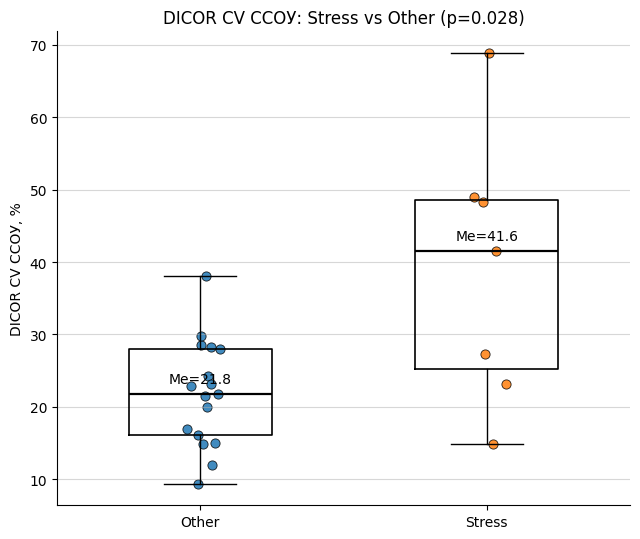

Рисунок сохранён: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\05_chords_adaptation_costs\figures\11_dicor_ssou_stress_vs_other.png


In [60]:
# ============================================================
# 31. Stress vs Other: DICOR CV ССОУ
# ============================================================

focus_var = "dicor_ssou_cv_pct"

plot_df = main_df.copy()
plot_df["stress_group"] = np.where(
    plot_df["adaptation_phenotype_ru"] == "Стресс-доминантный фенотип",
    "Stress",
    "Other"
)

group_order = ["Other", "Stress"]

fig, ax = plt.subplots(figsize=(6.5, 5.5))

data_by_group = [
    plot_df.loc[plot_df["stress_group"] == group, focus_var].dropna()
    for group in group_order
]

ax.boxplot(
    data_by_group,
    patch_artist=False,
    widths=0.5,
    boxprops=dict(color="black", linewidth=1.2),
    medianprops=dict(color="black", linewidth=1.6),
    whiskerprops=dict(color="black", linewidth=1.0),
    capprops=dict(color="black", linewidth=1.0),
    flierprops=dict(
        marker="o",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=4,
    ),
)

for i, values in enumerate(data_by_group, start=1):
    jitter = np.random.normal(loc=i, scale=0.04, size=len(values))
    ax.scatter(
        jitter,
        values,
        s=44,
        edgecolor="black",
        linewidth=0.6,
        alpha=0.85,
    )

median_other = np.median(data_by_group[0])
median_stress = np.median(data_by_group[1])

ax.text(1, median_other + 1.5, f"Me={median_other:.1f}", ha="center", fontsize=10)
ax.text(2, median_stress + 1.5, f"Me={median_stress:.1f}", ha="center", fontsize=10)

# p-value из твоего анализа
p_value = 0.028263

ax.set_title(f"DICOR CV ССОУ: Stress vs Other (p={p_value:.3f})")
ax.set_ylabel("DICOR CV ССОУ, %")
ax.set_xticklabels(group_order)

apply_publication_style(ax)

plt.tight_layout()

fig_path = FIGURES_DIR / "11_dicor_ssou_stress_vs_other.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Рисунок сохранён:", fig_path)

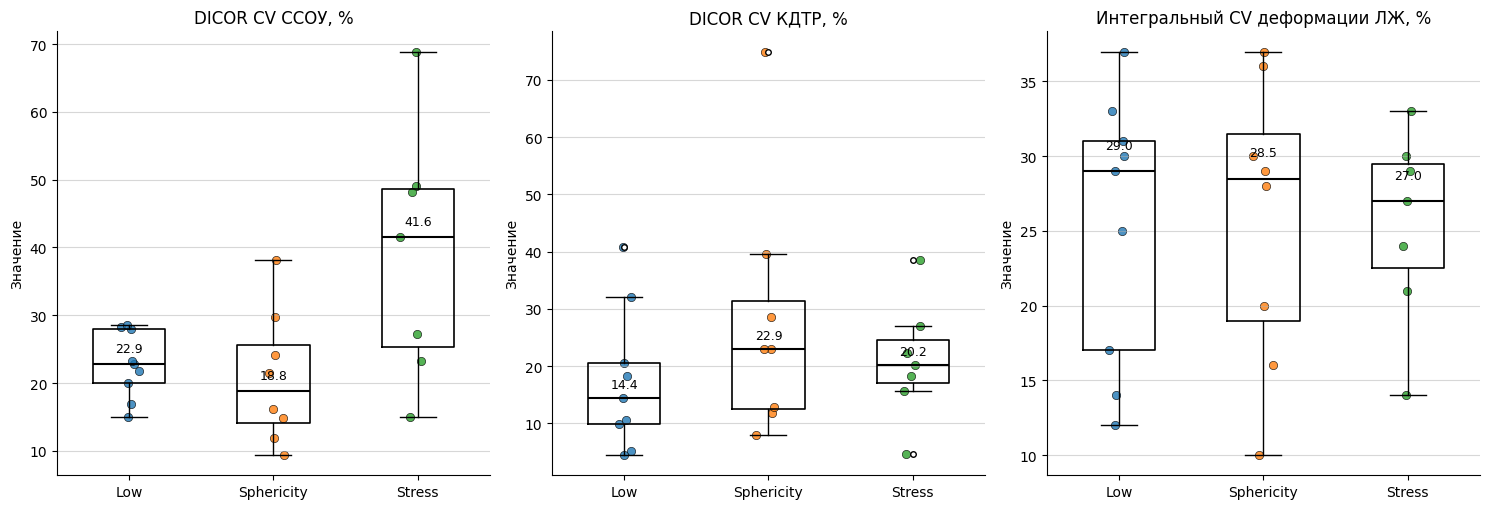

Рисунок сохранён: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\05_chords_adaptation_costs\figures\12_final_adaptation_cost_figure.png


In [61]:
# ============================================================
# 32. Итоговая figure: цена адаптации по трём ключевым показателям
# ============================================================

final_cost_vars = [
    "dicor_ssou_cv_pct",
    "dicor_sm_kdtr_cv_pct",
    "merged_lv_deformation_cv_pct",
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5.2))

for ax, col in zip(axes, final_cost_vars):
    data_by_group = [
        main_df.loc[
            main_df["adaptation_phenotype_ru"] == phenotype,
            col
        ].dropna()
        for phenotype in main_phenotype_order_ru
    ]

    ax.boxplot(
        data_by_group,
        patch_artist=False,
        widths=0.5,
        boxprops=dict(color="black", linewidth=1.2),
        medianprops=dict(color="black", linewidth=1.5),
        whiskerprops=dict(color="black", linewidth=1.0),
        capprops=dict(color="black", linewidth=1.0),
        flierprops=dict(
            marker="o",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=4,
        ),
    )

    for i, values in enumerate(data_by_group, start=1):
        jitter = np.random.normal(loc=i, scale=0.04, size=len(values))
        ax.scatter(
            jitter,
            values,
            s=36,
            edgecolor="black",
            linewidth=0.5,
            alpha=0.8,
        )

    # медианы
    medians = [np.median(values) for values in data_by_group]
    for i, med in enumerate(medians, start=1):
        ax.text(i, med + 1.3, f"{med:.1f}", ha="center", va="bottom", fontsize=9)

    ax.set_title(pretty_names.get(col, col))
    ax.set_ylabel("Значение")
    ax.set_xticklabels(["Low", "Sphericity", "Stress"])

    apply_publication_style(ax)

plt.tight_layout()

fig_path = FIGURES_DIR / "12_final_adaptation_cost_figure.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Рисунок сохранён:", fig_path)